# Détection automatique de faux billets (ONCFM)

**Organisation nationale de lutte contre le faux-monnayage**
Notebook d'analyse : traitements, modélisation et sélection du modèle final

---

## Contexte

L'ONCFM dispose d'une machine qui relève six dimensions géométriques sur chaque
billet reçu. L'organisation a constaté au fil des années que les contrefaçons
présentent des écarts de dimensions imperceptibles à l'œil nu mais mesurables.
L'objectif est de construire un algorithme qui décide, à partir de ces seules
six mesures, si un billet est authentique ou falsifié.

## L'enjeu métier détermine toute la démarche

Les deux erreurs possibles n'ont pas le même coût :

| Erreur | Conséquence | Coût                                            |
|---|---|-------------------------------------------------|
| **Un faux billet déclaré authentique** | La contrefaçon entre en circulation | Élevé : c'est précisément ce que l'ONCFM combat |
| **Un vrai billet déclaré faux** | Le billet part en vérification manuelle | Modéré : du temps agent, pas de préjudice       |

Cette asymétrie commande trois décisions qui structurent tout ce notebook :

1. l'**accuracy ne sera jamais** le critère de décision, avec 2 vrais billets
   pour 1 faux, un modèle qui répondrait « authentique » systématiquement
   afficherait déjà 66,7 % ;
2. la métrique prioritaire est le **rappel sur la classe « faux »** : la part
   des contrefaçons effectivement interceptées ;
3. le **seuil de décision sera ajusté** plutôt que laissé à 0,5, valeur qui
   suppose implicitement que les deux erreurs coûtent autant.

## Plan

1. Chargement et contrôle qualité
2. Analyse exploratoire
3. Stratégie de découpage des données
4. Traitement des valeurs manquantes : comparaison chiffrée des méthodes
5. Modélisation supervisée : régression logistique, KNN, random forest
6. Analyse non supervisée : k-means
7. Comparaison des modèles et choix du modèle final
8. Calibration du seuil de décision
9. Évaluation finale sur le jeu de test
10. Interprétation du modèle
11. Pipeline de production et sauvegarde
12. Limites et pistes d'amélioration

---
## 1. Configuration et chargement

Les composants personnalisés du pipeline (validation des colonnes, contrôle
d'intégrité, seuil de décision, k-means prédictif) sont définis dans le module
`script/oncfm_model.py` plutôt que dans ce notebook.

C'est un choix délibéré : `joblib` ne sérialise pas le code des classes
personnalisées, seulement une **référence** vers le module qui les définit. Des
classes déclarées dans un notebook seraient enregistrées comme appartenant à
`__main__`, et le modèle sauvegardé ne pourrait être rechargé que depuis un
contexte redéfinissant exactement les mêmes classes. En les isolant dans un
module importable, le fichier `.pkl` devient portable.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Composants personnalisés du projet
sys.path.insert(0, str(Path("../script").resolve()))
from oncfm_model import (
    FEATURES,
    ColumnValidator,
    RowIntegrityCheck,
    ThresholdClassifier,
    KMeansCentroidClassifier,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# Palette : le rouge signale les faux billets sur toutes les figures
COL_FAUX, COL_VRAI = "#C0392B", "#2471A3"
PALETTE = {False: COL_FAUX, True: COL_VRAI}

print("Variables géométriques :", ", ".join(FEATURES))

Variables géométriques : diagonal, height_left, height_right, margin_low, margin_up, length


In [2]:
df = pd.read_csv("../data/billets.csv", sep=";")

print(f"Dimensions du jeu de données : {df.shape[0]} billets, {df.shape[1]} colonnes")
df.head()

Dimensions du jeu de données : 1500 billets, 7 colonnes


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


---
## 2. Contrôle qualité

Avant toute analyse, quatre vérifications. L'objectif n'est pas de cocher une
case mais d'établir ce qu'on peut légitimement faire des données ensuite.

### 2.1 Doublons

Des lignes identiques poseraient un problème précis : réparties entre le jeu
d'entraînement et le jeu de test, elles feraient évaluer le modèle sur des
billets qu'il a déjà appris, gonflant artificiellement les performances.

In [4]:
n_exact = df.duplicated().sum()
n_mesures = df[FEATURES].duplicated().sum()

print(f"Lignes strictement identiques           : {n_exact}")
print(f"Billets aux 6 mesures identiques        : {n_mesures}")
print(
    "\nAucun doublon : chaque billet est une observation distincte."
    if n_exact == 0 and n_mesures == 0
    else "\nDoublons détectés, traitement nécessaire."
)

Lignes strictement identiques           : 0
Billets aux 6 mesures identiques        : 0

Aucun doublon : chaque billet est une observation distincte.


### 2.2 Valeurs manquantes

Le point clé n'est pas *combien* de valeurs manquent, mais **si elles manquent
au hasard**. Si les mesures absentes se concentraient sur une classe, les
imputer introduirait un biais systématique en faveur de cette classe.

In [5]:
na = df.isna().sum()
na = na[na > 0]

print("Valeurs manquantes par variable :")
for col, n in na.items():
    print(f"  {col:14s} {n:3d}  ({n / len(df):.2%})")

# Les valeurs manquantes se concentrent-elles sur une classe ?
manquant = df["margin_low"].isna()
table = pd.crosstab(df["is_genuine"], manquant)
table.columns = ["margin_low renseignée", "margin_low manquante"]
table.index = ["Faux billet", "Vrai billet"]

taux = table["margin_low manquante"] / table.sum(axis=1)
table["taux de valeurs manquantes"] = taux.map("{:.2%}".format)

chi2, p_value, _, _ = stats.chi2_contingency(
    pd.crosstab(df["is_genuine"], manquant)
)
print(f"\nTest du khi-deux d'indépendance : χ² = {chi2:.3f}, p = {p_value:.3f}")
table

Valeurs manquantes par variable :
  margin_low      37  (2.47%)

Test du khi-deux d'indépendance : χ² = 1.832, p = 0.176


,margin_low renseignée,margin_low manquante,taux de valeurs manquantes
Faux billet,492,8,1.60%
Vrai billet,971,29,2.90%


**Lecture.** Les valeurs manquantes touchent 2,9 % des vrais billets et 1,6 %
des faux. Le test du khi-deux donne p = 0,176 : bien au-dessus du seuil usuel
de 0,05, on ne peut pas rejeter l'hypothèse d'indépendance entre l'absence de
mesure et la nature du billet.

Concrètement : rien n'indique que la machine échoue davantage sur les
contrefaçons. L'imputation ne risque donc pas d'introduire un biais orienté
vers une classe. C'est cette vérification qui autorise à imputer plutôt qu'à
supprimer, et supprimer 37 billets sur 1 500 serait de toute façon une perte
d'information inutile.

### 2.3 Valeurs aberrantes

Une marge négative ou un billet de 90 mm signalerait une défaillance du
capteur. On vérifie plutôt que d'affirmer.

In [6]:
desc = df[FEATURES].describe().T
desc["étendue"] = desc["max"] - desc["min"]
desc["coef. variation"] = desc["std"] / desc["mean"]
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,étendue,coef. variation
diagonal,1500.0,171.958,0.305,171.04,171.750,171.96,172.17,173.01,1.97,0.002
height_left,1500.0,104.030,0.299,103.14,103.820,104.04,104.23,104.88,1.74,0.003
height_right,1500.0,103.920,0.326,102.82,103.710,103.92,104.15,104.95,2.13,0.003
margin_low,1463.0,4.486,0.664,2.98,4.015,4.31,4.87,6.90,3.92,0.148
margin_up,1500.0,3.151,0.232,2.27,2.990,3.14,3.31,3.91,1.64,0.074
length,1500.0,112.678,0.873,109.49,112.030,112.96,113.34,114.44,4.95,0.008


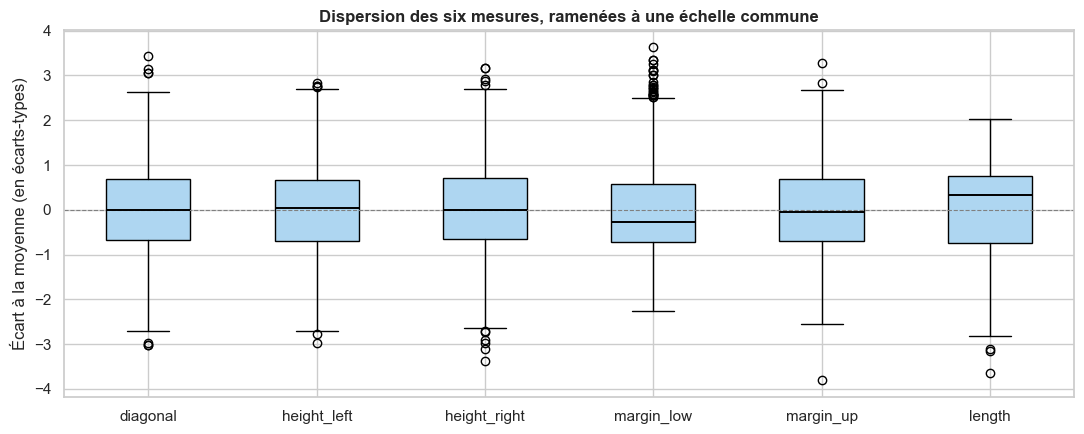

Nombre de billets au-delà de 4 écarts-types, par variable :
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0


In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
donnees = [df[c].dropna() for c in FEATURES]
bp = ax.boxplot(
    [(s - s.mean()) / s.std() for s in donnees],
    labels=FEATURES,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.4),
)
for patch in bp["boxes"]:
    patch.set_facecolor("#AED6F1")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_ylabel("Écart à la moyenne (en écarts-types)")
ax.set_title("Dispersion des six mesures, ramenées à une échelle commune")
plt.tight_layout()
plt.show()

extremes = ((df[FEATURES] - df[FEATURES].mean()).abs() / df[FEATURES].std() > 4).sum()
print("Nombre de billets au-delà de 4 écarts-types, par variable :")
print(extremes.to_string())

**Lecture.** Aucune valeur n'est physiquement absurde. Les points hors des
moustaches restent dans des plages plausibles pour des billets : un billet
mesurant 109,5 mm de long au lieu de 112,7 mm en moyenne est court, mais c'est
justement ce qu'on attend d'une contrefaçon.

**Décision : aucune suppression d'outlier.** Retirer ces billets reviendrait à
supprimer précisément le signal qu'on cherche à détecter. C'est un piège
classique : le traitement des valeurs extrêmes ne doit jamais être appliqué
mécaniquement quand les valeurs extrêmes *sont* le phénomène étudié.

---
## 3. Analyse exploratoire

### 3.1 Répartition des classes

Vrais billets : 1000  (66.7%)
Faux billets  :  500  (33.3%)

Ratio : 2.0 vrais pour 1 faux

Un modèle répondant « authentique » à tous les billets obtiendrait 66.7% d'accuracy
sans détecter le moindre faux billet. C'est le point de comparaison à garder en tête.


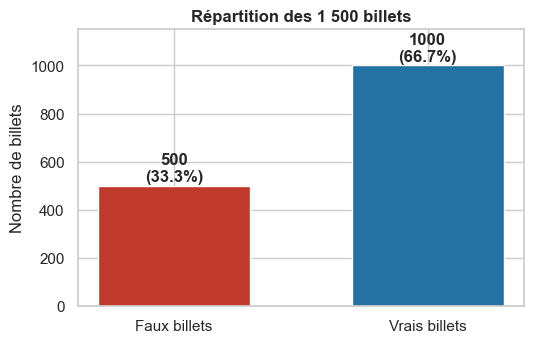

In [8]:
counts = df["is_genuine"].value_counts()
props = df["is_genuine"].value_counts(normalize=True)

print(f"Vrais billets : {counts[True]:4d}  ({props[True]:.1%})")
print(f"Faux billets  : {counts[False]:4d}  ({props[False]:.1%})")
print(f"\nRatio : {counts[True] / counts[False]:.1f} vrais pour 1 faux")
print(
    f"\nUn modèle répondant « authentique » à tous les billets obtiendrait "
    f"{props[True]:.1%} d'accuracy\nsans détecter le moindre faux billet. "
    f"C'est le point de comparaison à garder en tête."
)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(
    ["Faux billets", "Vrais billets"],
    [counts[False], counts[True]],
    color=[COL_FAUX, COL_VRAI],
    width=0.6,
)
for i, v in enumerate([counts[False], counts[True]]):
    ax.text(i, v + 18, f"{v}\n({v / len(df):.1%})", ha="center", fontweight="bold")
ax.set_ylim(0, 1150)
ax.set_ylabel("Nombre de billets")
ax.set_title("Répartition des 1 500 billets")
plt.tight_layout()
plt.show()

### 3.2 Distribution des variables selon la nature du billet

C'est ici qu'on identifie quelles mesures portent l'information.

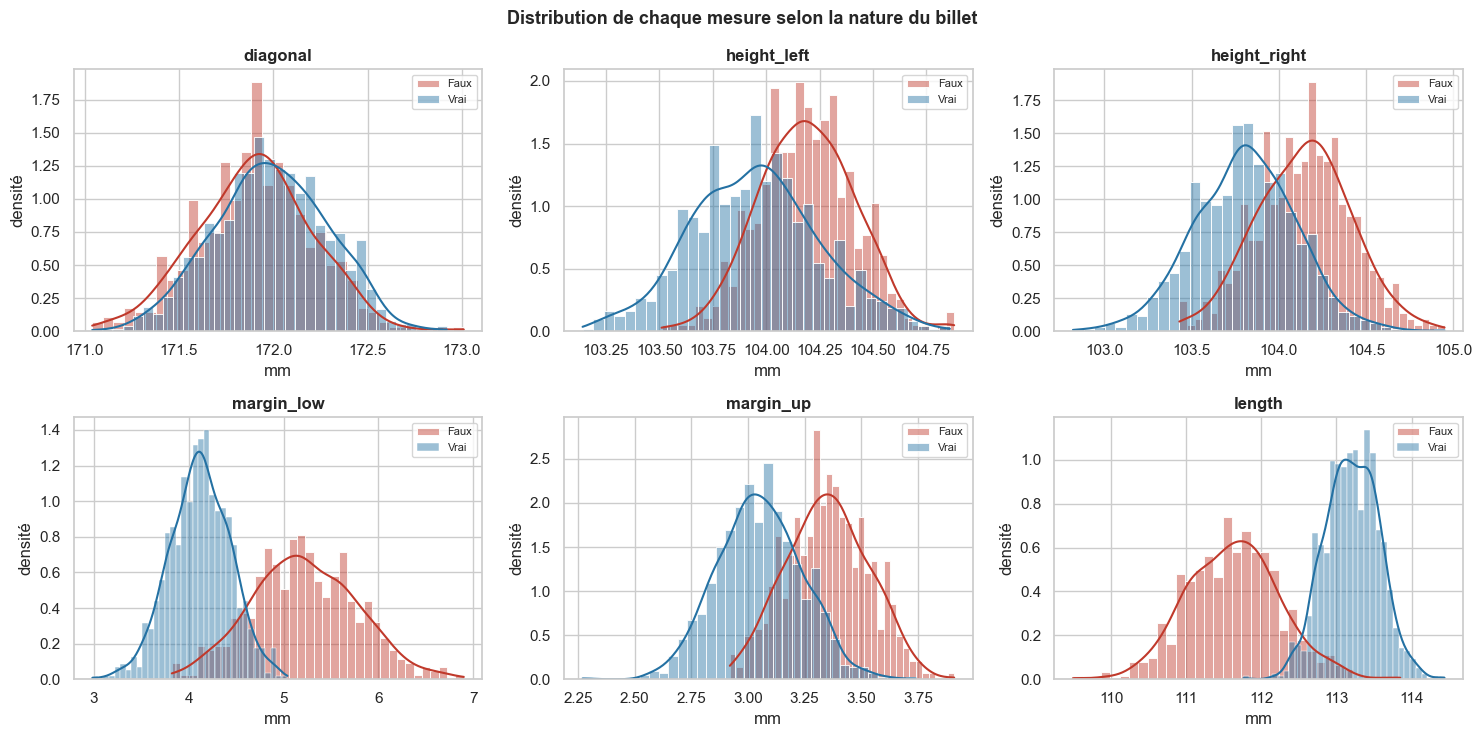

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, var in zip(axes.flatten(), FEATURES):
    for genuine, couleur, etiquette in [
        (False, COL_FAUX, "Faux"),
        (True, COL_VRAI, "Vrai"),
    ]:
        sns.histplot(
            df.loc[df["is_genuine"] == genuine, var].dropna(),
            ax=ax,
            color=couleur,
            label=etiquette,
            kde=True,
            stat="density",
            alpha=0.45,
            bins=35,
            edgecolor=None,
        )
    ax.set_title(var)
    ax.set_xlabel("mm")
    ax.set_ylabel("densité")
    ax.legend(fontsize=8)
fig.suptitle(
    "Distribution de chaque mesure selon la nature du billet",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### 3.3 Quantifier le pouvoir discriminant

Le graphique ci-dessus se lit à l'œil ; on le chiffre avec le **d de Cohen**,
qui mesure l'écart entre les moyennes des deux groupes exprimé en écarts-types.
Contrairement à la corrélation, il ne dépend pas de l'équilibre des classes et
s'interprète directement : |d| > 0,8 correspond à un effet fort, |d| < 0,2 à un
effet négligeable.

In [10]:
lignes = []
for var in FEATURES:
    vrais = df.loc[df["is_genuine"], var].dropna()
    faux = df.loc[~df["is_genuine"], var].dropna()
    s_pool = np.sqrt(
        ((len(vrais) - 1) * vrais.var() + (len(faux) - 1) * faux.var())
        / (len(vrais) + len(faux) - 2)
    )
    lignes.append(
        {
            "Variable": var,
            "Moyenne vrais": vrais.mean(),
            "Moyenne faux": faux.mean(),
            "Écart (mm)": vrais.mean() - faux.mean(),
            "d de Cohen": (vrais.mean() - faux.mean()) / s_pool,
            "Corrélation": df[var].corr(df["is_genuine"].astype(int)),
        }
    )

pouvoir = (
    pd.DataFrame(lignes)
    .assign(abs_d=lambda t: t["d de Cohen"].abs())
    .sort_values("abs_d", ascending=False)
    .drop(columns="abs_d")
    .reset_index(drop=True)
)
pouvoir.round(3)

,Variable,Moyenne vrais,Moyenne faux,Écart (mm),d de Cohen,Corrélation
0,length,113.202,111.631,1.572,3.410,0.849
1,margin_low,4.116,5.216,-1.100,-2.663,-0.783
2,margin_up,3.052,3.350,-0.298,-1.616,-0.606
3,height_right,103.809,104.144,-0.335,-1.176,-0.485
4,height_left,103.949,104.190,-0.241,-0.870,-0.380
5,diagonal,171.987,171.901,0.086,0.284,0.133


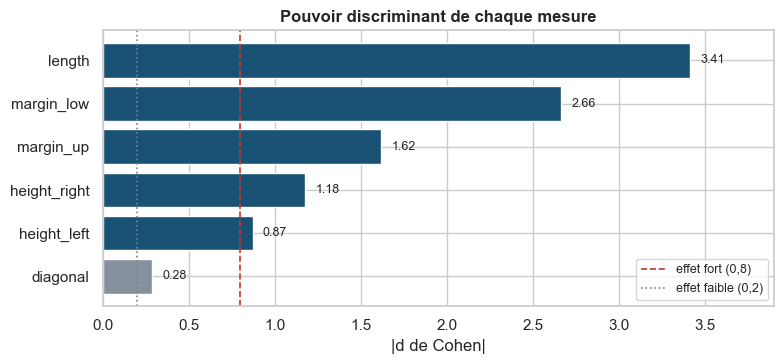

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8))
couleurs = ["#1A5276" if abs(d) > 0.8 else "#85929E" for d in pouvoir["d de Cohen"]]
ax.barh(pouvoir["Variable"], pouvoir["d de Cohen"].abs(), color=couleurs)
ax.axvline(0.8, color=COL_FAUX, linestyle="--", linewidth=1.2, label="effet fort (0,8)")
ax.axvline(0.2, color="grey", linestyle=":", linewidth=1.2, label="effet faible (0,2)")
for i, (v, d) in enumerate(zip(pouvoir["Variable"], pouvoir["d de Cohen"])):
    ax.text(abs(d) + 0.06, i, f"{abs(d):.2f}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("|d de Cohen|")
ax.set_xlim(0, 3.9)
ax.set_title("Pouvoir discriminant de chaque mesure")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Lecture.** Une hiérarchie nette se dégage :

- `length` (d = 3,41) est de très loin la mesure la plus informative : les vrais
  billets sont en moyenne **1,57 mm plus longs** que les faux ;
- `margin_low` (d = −2,66) suit : les contrefaçons ont une marge inférieure
  sensiblement plus large ;
- `margin_up`, `height_right` et `height_left` apportent un signal réel mais
  décroissant ;
- `diagonal` (d = 0,28) est **quasiment inutile** prise isolément.

La question de retirer `diagonal` se pose donc. Elle sera tranchée par la
mesure en section 7.4, pas par intuition.

### 3.4 Corrélations

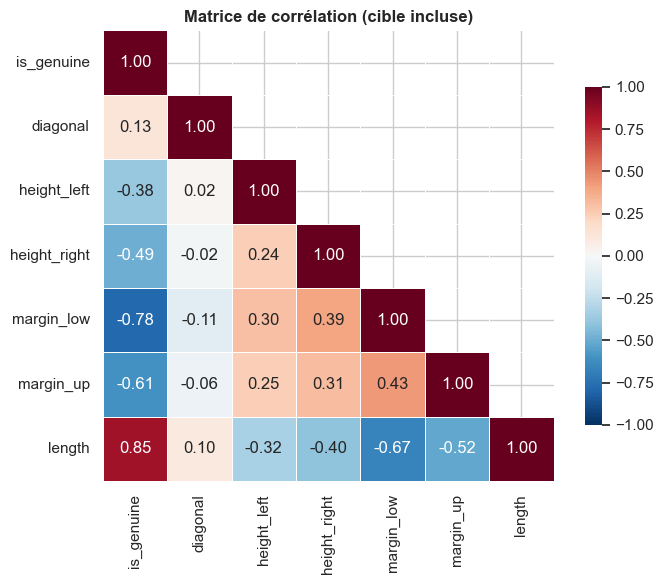

In [12]:
corr = df.assign(is_genuine=df["is_genuine"].astype(int)).corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
masque = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=masque,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Matrice de corrélation (cible incluse)")
plt.tight_layout()
plt.show()

**Lecture.** Deux enseignements.

D'abord, les corrélations avec la cible confirment la hiérarchie : `length`
(0,85), `margin_low` (−0,78), `margin_up` (−0,61).

Ensuite, et c'est utile pour la suite, **les variables explicatives sont
corrélées entre elles** : `margin_low` avec `length` et avec les hauteurs. Cette
redondance est une bonne nouvelle pour l'imputation : une mesure manquante peut
être reconstruite à partir des cinq autres, ce qui est précisément la stratégie
testée en section 5.

### 3.5 Projection en deux dimensions

Une analyse en composantes principales permet de voir la structure d'ensemble
du nuage. Cette projection resservira telle quelle pour juger la forme des
clusters dans la partie non supervisée.

Variance expliquée par composante :
  CP1 : 43.1%   (cumul 43.1%)
  CP2 : 17.0%   (cumul 60.1%)
  CP3 : 13.1%   (cumul 73.2%)
  CP4 : 11.8%   (cumul 85.0%)
  CP5 : 9.6%   (cumul 94.6%)
  CP6 : 5.4%   (cumul 100.0%)


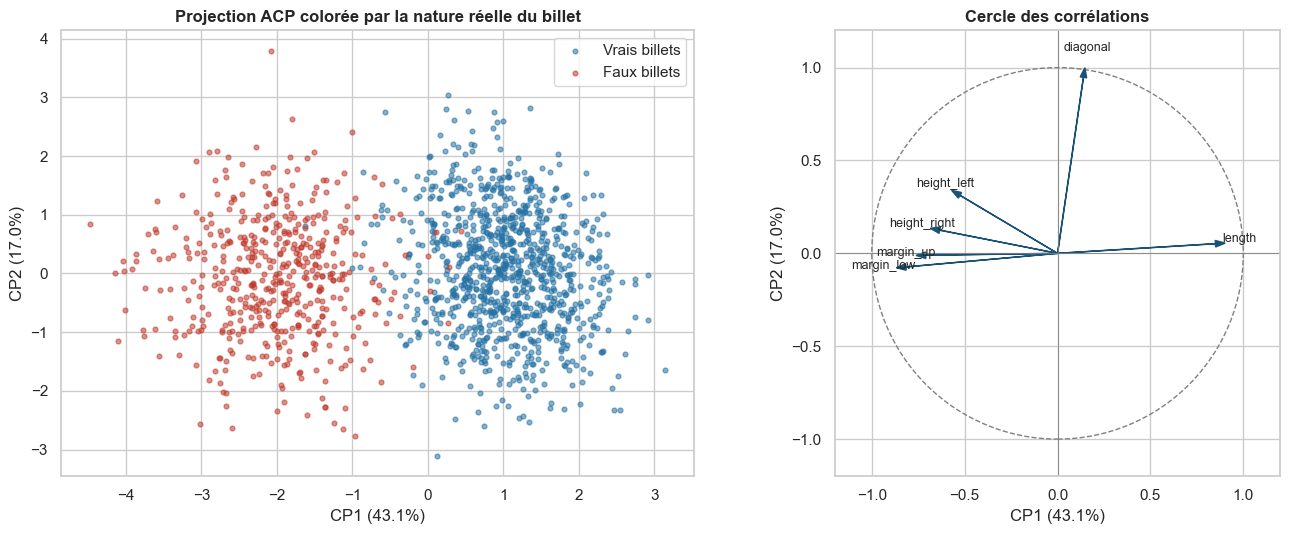

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

complet = df.dropna(subset=FEATURES)
Z = StandardScaler().fit_transform(complet[FEATURES])
acp = PCA(n_components=6).fit(Z)
coords = acp.transform(Z)

var_expl = acp.explained_variance_ratio_
print("Variance expliquée par composante :")
for i, v in enumerate(var_expl, 1):
    print(f"  CP{i} : {v:.1%}   (cumul {var_expl[:i].sum():.1%})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for genuine, couleur, etiquette in [
    (True, COL_VRAI, "Vrais billets"),
    (False, COL_FAUX, "Faux billets"),
]:
    m = complet["is_genuine"].to_numpy() == genuine
    ax1.scatter(
        coords[m, 0], coords[m, 1], s=12, c=couleur, alpha=0.55, label=etiquette
    )
ax1.set_xlabel(f"CP1 ({var_expl[0]:.1%})")
ax1.set_ylabel(f"CP2 ({var_expl[1]:.1%})")
ax1.set_title("Projection ACP colorée par la nature réelle du billet")
ax1.legend()

# Cercle des corrélations
charges = acp.components_[:2].T * np.sqrt(acp.explained_variance_[:2])
cercle = plt.Circle((0, 0), 1, color="grey", fill=False, linestyle="--")
ax2.add_artist(cercle)
for i, var in enumerate(FEATURES):
    ax2.arrow(0, 0, charges[i, 0], charges[i, 1], head_width=0.035, color="#1A5276")
    ax2.text(charges[i, 0] * 1.15, charges[i, 1] * 1.15, var, ha="center", fontsize=9)
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.axhline(0, color="grey", lw=0.6)
ax2.axvline(0, color="grey", lw=0.6)
ax2.set_aspect("equal")
ax2.set_xlabel(f"CP1 ({var_expl[0]:.1%})")
ax2.set_ylabel(f"CP2 ({var_expl[1]:.1%})")
ax2.set_title("Cercle des corrélations")

plt.tight_layout()
plt.show()

**Lecture.** Les deux classes forment deux nuages largement séparés le long de
la première composante, avec une zone de recouvrement étroite au centre.

Ce constat pose une attente réaliste pour la suite : **tous les modèles vont
obtenir des performances élevées et très proches les unes des autres**, parce
que le problème est intrinsèquement facile. Les quelques billets de la zone de
recouvrement constitueront l'essentiel des erreurs, quel que soit
l'algorithme. Il faudra donc se garder de conclure qu'un modèle est « meilleur »
sur la foi d'un ou deux billets d'écart.

Le cercle des corrélations montre que `length` s'oppose à `margin_low` et
`margin_up` sur le premier axe : c'est bien cette opposition qui porte la
séparation. `diagonal`, flèche courte, contribue peu.

Une réserve de lecture : les deux premières composantes ne restituent que
60,4 % de l'information totale. Une séparation apparente sur ce plan ne
garantit pas une séparation dans l'espace complet, et inversement.

---
## 4. Stratégie de découpage des données

C'est la section la plus importante du notebook sur le plan méthodologique.

### Le principe

Toute décision prise en regardant un jeu de données rend ce jeu inutilisable
pour estimer honnêtement la performance. Cela vaut pour le choix du modèle,
pour les hyperparamètres, **et pour le seuil de décision** : un point souvent
négligé. Si l'on essaie plusieurs seuils sur le jeu de test et qu'on retient
celui qui donne le meilleur résultat, le chiffre annoncé n'est plus une
prédiction de performance future : c'est la valeur qu'on a optimisée.

### Le protocole retenu

| Étape | Données utilisées | Ce qui s'y décide |
|---|---|---|
| **1. Découpage** | 1 500 billets | 80 % entraînement / 20 % test, stratifié |
| **2. Toutes les décisions** | 1 200 billets d'entraînement, **par validation croisée** | méthode d'imputation, hyperparamètres, choix du modèle, seuil |
| **3. Mesure finale** | 300 billets de test, **ouverts une seule fois** | estimation honnête de la performance |

Le jeu de test est mis de côté maintenant et n'est plus consulté avant la
section 10. Pour la calibration du seuil, on utilisera `cross_val_predict` :
chaque billet d'entraînement reçoit une probabilité prédite par un modèle qui
ne l'a jamais vu pendant son apprentissage. On calibre donc le seuil sur des
prédictions hors-échantillon, sans jamais toucher au test.

In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df[FEATURES].copy()
y = df["is_genuine"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,       # conserve le ratio 2:1 dans les deux jeux
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Entraînement : {len(X_train):4d} billets   "
      f"({(~y_train).sum()} faux, {y_train.sum()} vrais : "
      f"{y_train.mean():.1%} de vrais)")
print(f"Test         : {len(X_test):4d} billets   "
      f"({(~y_test).sum()} faux, {y_test.sum()} vrais : "
      f"{y_test.mean():.1%} de vrais)")
print(f"\nValeurs manquantes  |  entraînement : {int(X_train.isna().sum().sum())}"
      f"   test : {int(X_test.isna().sum().sum())}")
print("\nLa stratification a préservé exactement la proportion des classes.")

Entraînement : 1200 billets   (400 faux, 800 vrais : 66.7% de vrais)
Test         :  300 billets   (100 faux, 200 vrais : 66.7% de vrais)

Valeurs manquantes  |  entraînement : 25   test : 12

La stratification a préservé exactement la proportion des classes.


---
## 5. Traitement des valeurs manquantes

37 valeurs de `margin_low` sont absentes, soit 2,5 % du jeu. Plutôt que de
choisir une méthode par habitude, on les met en concurrence sur une mesure
objective.

### Protocole

On ne peut pas évaluer une imputation sur des valeurs qu'on ignore. On procède
donc par masquage contrôlé, **sur le jeu d'entraînement uniquement** :

1. on isole les billets d'entraînement dont les six mesures sont connues ;
2. on masque artificiellement des valeurs de `margin_low`, dans la même
   proportion que les manquants réels (2,1 %) ;
3. chaque méthode reconstruit les valeurs masquées ;
4. on compare à la vérité par l'erreur quadratique moyenne (RMSE).

L'opération est répétée **30 fois** avec des masques différents, pour que le
classement ne dépende pas d'un tirage particulier.

Les méthodes en lice :

- **moyenne** et **médiane** : remplacement par une constante ;
- **KNN brut** : moyenne des 5 billets les plus proches, sur données non
  standardisées ;
- **KNN standardisé** (k = 5 et k = 10) : le KNN calcule des distances
  euclidiennes ; sans mise à l'échelle préalable, `length` (écart-type 0,87)
  pèse près de trois fois plus que `diagonal` (0,31) dans le choix des voisins.
  Standardiser corrige ce déséquilibre ;
- **régression linéaire** (`IterativeImputer`) : `margin_low` est prédite à
  partir des cinq autres mesures. C'est la méthode qui exploite le plus
  directement la redondance constatée en section 3.4.

In [15]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression

complets_train = X_train.dropna()
taux_manquant = X_train["margin_low"].isna().mean()
n_masque = int(round(taux_manquant * len(complets_train)))

print(f"Billets d'entraînement complets : {len(complets_train)}")
print(f"Taux de valeurs manquantes réel : {taux_manquant:.2%}")
print(f"Valeurs masquées par répétition : {n_masque}")
print(f"Écart-type de margin_low        : {complets_train['margin_low'].std():.4f} mm")


def imputer_knn_standardise(donnees, k):
    '''KNNImputer appliqué sur données standardisées, puis retour à l'échelle d'origine.'''
    echelle = StandardScaler().fit(donnees)
    centre = pd.DataFrame(echelle.transform(donnees), columns=donnees.columns)
    complete = KNNImputer(n_neighbors=k).fit_transform(centre)
    return pd.DataFrame(echelle.inverse_transform(complete), columns=donnees.columns)


METHODES = {
    "Moyenne": lambda d: pd.DataFrame(
        SimpleImputer(strategy="mean").fit_transform(d), columns=d.columns),
    "Médiane": lambda d: pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(d), columns=d.columns),
    "KNN (k=5, brut)": lambda d: pd.DataFrame(
        KNNImputer(n_neighbors=5).fit_transform(d), columns=d.columns),
    "KNN (k=5, standardisé)": lambda d: imputer_knn_standardise(d, 5),
    "KNN (k=10, standardisé)": lambda d: imputer_knn_standardise(d, 10),
    "Régression linéaire": lambda d: pd.DataFrame(
        IterativeImputer(estimator=LinearRegression(), max_iter=20,
                         random_state=0).fit_transform(d), columns=d.columns),
}

resultats = {nom: [] for nom in METHODES}
tirage = np.random.RandomState(0)

for _ in range(30):
    positions = tirage.choice(len(complets_train), size=n_masque, replace=False)
    verite = complets_train["margin_low"].to_numpy()[positions].copy()

    troue = complets_train.copy()
    troue.iloc[positions, troue.columns.get_loc("margin_low")] = np.nan

    for nom, fonction in METHODES.items():
        estime = fonction(troue)["margin_low"].to_numpy()[positions]
        resultats[nom].append(np.sqrt(np.mean((estime - verite) ** 2)))

benchmark = (
    pd.DataFrame(
        {
            "RMSE moyen (mm)": {k: np.mean(v) for k, v in resultats.items()},
            "Écart-type": {k: np.std(v) for k, v in resultats.items()},
        }
    )
    .sort_values("RMSE moyen (mm)")
)
benchmark["Gain vs médiane"] = (
    1 - benchmark["RMSE moyen (mm)"] / benchmark.loc["Médiane", "RMSE moyen (mm)"]
).map("{:+.1%}".format)
benchmark.round(4)

Billets d'entraînement complets : 1175
Taux de valeurs manquantes réel : 2.08%
Valeurs masquées par répétition : 24
Écart-type de margin_low        : 0.6561 mm


,RMSE moyen (mm),Écart-type,Gain vs médiane
Régression linéaire,0.4529,0.0688,+28.7%
"KNN (k=10, standardisé)",0.4564,0.0784,+28.2%
"KNN (k=5, standardisé)",0.4681,0.0790,+26.3%
"KNN (k=5, brut)",0.4826,0.0794,+24.1%
Moyenne,0.6216,0.0836,+2.2%
Médiane,0.6354,0.1009,+0.0%


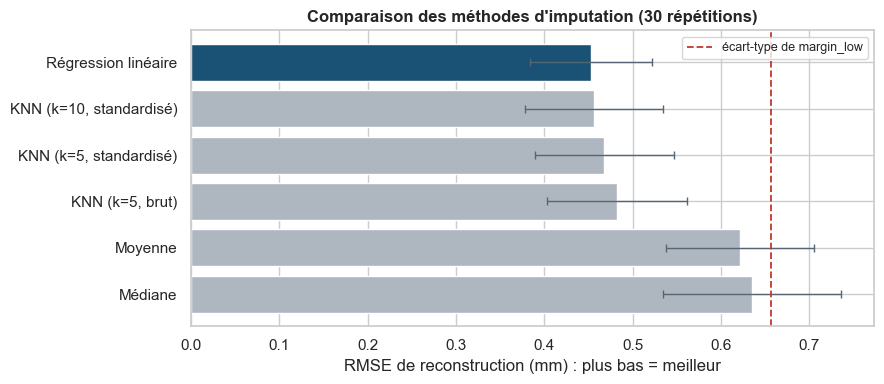

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ordre = benchmark.index[::-1]
couleurs = ["#1A5276" if n == benchmark.index[0] else "#AEB6BF" for n in ordre]
ax.barh(ordre, benchmark.loc[ordre, "RMSE moyen (mm)"],
        xerr=benchmark.loc[ordre, "Écart-type"], color=couleurs,
        error_kw=dict(ecolor="#566573", capsize=3, lw=1))
ax.axvline(complets_train["margin_low"].std(), color=COL_FAUX, linestyle="--",
           lw=1.3, label="écart-type de margin_low")
ax.set_xlabel("RMSE de reconstruction (mm) : plus bas = meilleur")
ax.set_title("Comparaison des méthodes d'imputation (30 répétitions)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Lecture et décision.**

La **régression linéaire l'emporte** avec un RMSE de 0,453 mm, contre 0,635 mm
pour la médiane : une réduction de 29 % de l'erreur de reconstruction.

Trois observations méritent d'être relevées :

1. **L'imputation par une constante est proche du hasard.** Le RMSE de la
   moyenne (0,622) est presque égal à l'écart-type de `margin_low` (0,656) :
   c'est mathématiquement attendu, et cela signifie que cette méthode n'exploite
   aucune information. Elle écraserait par ailleurs la variance de la variable
   la deuxième plus discriminante du jeu.
2. **Standardiser avant le KNN améliore bien le résultat** (0,468 contre
   0,483), ce qui confirme le raisonnement sur les distances euclidiennes.
3. **La régression linéaire et le KNN standardisé sont très proches**
   (0,453 contre 0,456 pour k = 10), l'écart étant inférieur aux écarts-types.
   On retient la régression linéaire pour deux raisons pratiques : elle est
   déterministe, et elle est plus rapide à l'application, ce qui compte pour un
   modèle appelé en production sur des lots quotidiens.

**Sur la suppression pure et simple** : elle reste envisageable puisque les
valeurs manquent au hasard (section 2.2). Elle est écartée parce qu'elle
sacrifie 37 billets sans nécessité, et surtout parce qu'elle ne réglerait
**rien en production** : un billet arrivant avec une mesure manquante devrait
tout de même être classé. L'imputation doit vivre dans le pipeline.

In [17]:
def construire_imputeur():
    '''Imputeur retenu : régression linéaire sur les autres dimensions.'''
    return IterativeImputer(estimator=LinearRegression(), max_iter=20, random_state=0)


demo = construire_imputeur().fit(X_train)
avant = X_train[X_train["margin_low"].isna()]
apres = pd.DataFrame(demo.transform(avant), columns=FEATURES, index=avant.index)

print(f"Exemple : les {len(avant)} billets d'entraînement à imputer\n")
apercu = avant.head(5).copy()
apercu["margin_low → imputée"] = apres.loc[apercu.index, "margin_low"].round(3)
apercu[["length", "margin_up", "height_left", "margin_low", "margin_low → imputée"]]

Exemple : les 25 billets d'entraînement à imputer



,length,margin_up,height_left,margin_low,margin_low → imputée
946,112.68,3.27,103.87,NaN,4.685
845,113.62,2.90,104.21,NaN,4.093
151,112.93,3.02,103.80,NaN,4.399
739,112.41,3.09,103.74,NaN,4.476
334,113.36,3.00,103.70,NaN,4.121


---
## 6. Modélisation supervisée

### 6.1 Le critère d'optimisation

Chaque modèle est optimisé sur le **F-bêta avec β = 2**, calculé sur la classe
« faux billet ».

Pourquoi pas le rappel seul ? Parce qu'il est trivialement maximisable : un
modèle déclarant « faux » pour tous les billets atteint un rappel de 1,00 tout
en étant inutilisable. Optimiser le rappel pur, c'est inviter la recherche
d'hyperparamètres à converger vers cette solution dégénérée.

Le F-bêta combine rappel et précision en pondérant le rappel β² = 4 fois plus.
Il traduit donc l'asymétrie des coûts métier tout en interdisant la solution
dégénérée. C'est ce même critère qui servira à choisir le seuil en section 9 :
la cohérence entre critère de sélection et critère de décision évite un défaut
courant, celui de sélectionner un modèle dans des conditions différentes de
celles où il servira.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, fbeta_score, recall_score, precision_score

# β = 2 : le rappel pèse 4 fois plus que la précision
fbeta2_faux = make_scorer(fbeta_score, beta=2, pos_label=False)

SCORINGS = {
    "accuracy": "accuracy",
    "precision_faux": make_scorer(precision_score, pos_label=False),
    "recall_faux": make_scorer(recall_score, pos_label=False),
    "fbeta2_faux": fbeta2_faux,
    "roc_auc": "roc_auc",
}

print("Critère d'optimisation : F-bêta (β=2) sur la classe « faux billet »")
print("Validation croisée     : 5 plis stratifiés, mélangés")

Critère d'optimisation : F-bêta (β=2) sur la classe « faux billet »
Validation croisée     : 5 plis stratifiés, mélangés


### 6.2 Régression logistique

Modèle de référence. Il estime directement une probabilité d'appartenance via
la fonction logistique. La standardisation est indispensable : la régularisation
pénalise les coefficients, et sans mise à l'échelle commune elle pénaliserait
plus lourdement les variables exprimées dans de petites unités.

L'hyperparamètre `C` contrôle l'intensité de la régularisation ; plus il est
faible, plus le modèle est contraint.

In [19]:
pipe_logistique = Pipeline([
    ("imputation", construire_imputeur()),
    ("standardisation", StandardScaler()),
    ("modele", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

grille_logistique = {"modele__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

gs_logistique = GridSearchCV(
    pipe_logistique, grille_logistique, scoring=fbeta2_faux, cv=cv, n_jobs=-1
).fit(X_train, y_train)

print(f"Meilleur C           : {gs_logistique.best_params_['modele__C']}")
print(f"F-bêta(2) validation : {gs_logistique.best_score_:.4f}")

resultats_C = pd.DataFrame({
    "C": grille_logistique["modele__C"],
    "F-bêta(2)": gs_logistique.cv_results_["mean_test_score"],
    "écart-type": gs_logistique.cv_results_["std_test_score"],
})
resultats_C.round(4)

Meilleur C           : 1
F-bêta(2) validation : 0.9829


,C,F-bêta(2),écart-type
0,0.001,0.6846,0.0436
1,0.010,0.9586,0.0122
2,0.100,0.9764,0.0143
3,1.000,0.9829,0.0132
4,10.000,0.9794,0.0100
5,100.000,0.9794,0.0100
6,1000.000,0.9794,0.0100


### 6.3 K plus proches voisins

Le KNN classe un billet par vote parmi ses k voisins les plus proches. Le choix
de k n'est pas laissé à sa valeur par défaut : on le balaie de 1 à 29.

Un k trop faible rend le modèle sensible au bruit ; un k trop élevé lisse
excessivement les frontières. La standardisation est ici encore plus critique
que pour la régression logistique, puisque l'algorithme *est* une distance.

Meilleurs paramètres : {'modele__n_neighbors': 11, 'modele__weights': 'uniform'}
F-bêta(2) validation : 0.9829


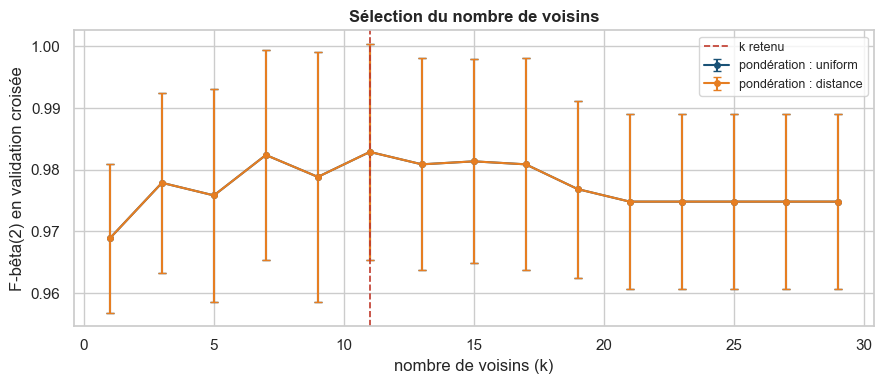

In [20]:
pipe_knn = Pipeline([
    ("imputation", construire_imputeur()),
    ("standardisation", StandardScaler()),
    ("modele", KNeighborsClassifier()),
])

grille_knn = {
    "modele__n_neighbors": list(range(1, 30, 2)),
    "modele__weights": ["uniform", "distance"],
}

gs_knn = GridSearchCV(
    pipe_knn, grille_knn, scoring=fbeta2_faux, cv=cv, n_jobs=-1
).fit(X_train, y_train)

print(f"Meilleurs paramètres : {gs_knn.best_params_}")
print(f"F-bêta(2) validation : {gs_knn.best_score_:.4f}")

res_knn = pd.DataFrame(gs_knn.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
for ponderation, couleur in [("uniform", "#1A5276"), ("distance", "#E67E22")]:
    sous = res_knn[res_knn["param_modele__weights"] == ponderation]
    ax.errorbar(
        sous["param_modele__n_neighbors"].astype(int),
        sous["mean_test_score"],
        yerr=sous["std_test_score"],
        marker="o", markersize=4, capsize=3, label=f"pondération : {ponderation}",
        color=couleur,
    )
ax.axvline(gs_knn.best_params_["modele__n_neighbors"], color=COL_FAUX,
           linestyle="--", lw=1.2, label="k retenu")
ax.set_xlabel("nombre de voisins (k)")
ax.set_ylabel("F-bêta(2) en validation croisée")
ax.set_title("Sélection du nombre de voisins")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Forêt aléatoire

Ensemble d'arbres de décision entraînés sur des échantillons et des
sous-ensembles de variables différents, dont on agrège les votes.

**Aucune standardisation ici** : un arbre découpe l'espace par des seuils du
type « length < 112,3 ». Multiplier une variable par une constante déplace le
seuil mais ne change pas la partition. Le modèle est donc indifférent à
l'échelle, c'est une propriété structurelle, pas un oubli.

In [21]:
pipe_foret = Pipeline([
    ("imputation", construire_imputeur()),
    ("modele", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

grille_foret = {
    "modele__n_estimators": [100, 300],
    "modele__max_depth": [None, 5, 10],
    "modele__min_samples_leaf": [1, 2, 5],
}

gs_foret = GridSearchCV(
    pipe_foret, grille_foret, scoring=fbeta2_faux, cv=cv, n_jobs=-1
).fit(X_train, y_train)

print(f"Meilleurs paramètres : {gs_foret.best_params_}")
print(f"F-bêta(2) validation : {gs_foret.best_score_:.4f}")

Meilleurs paramètres : {'modele__max_depth': None, 'modele__min_samples_leaf': 2, 'modele__n_estimators': 100}
F-bêta(2) validation : 0.9829


---
## 7. Analyse non supervisée : k-means

Le cahier des charges demande un k-means « duquel seront utilisés les centroïdes
pour réaliser la prédiction ». Le traiter comme un simple quatrième classifieur
passerait à côté de ce que cette méthode apporte réellement. On mène donc une
véritable analyse de clustering avant de l'utiliser en prédiction.

**Une précision de vocabulaire s'impose d'emblée.** Le k-means est non
supervisé : il regroupe les billets sans connaître les étiquettes. Mais pour
*prédire*, il faut savoir quel groupe correspond aux faux ; cette
correspondance ne peut être établie qu'en consultant les étiquettes. La méthode
est donc **hybride** : regroupement non supervisé, puis affectation supervisée
des groupes aux classes.

### 7.1 Combien de clusters ?

On sait qu'on cherche deux catégories, mais rien ne garantit que la structure
naturelle des données en comporte exactement deux. On le vérifie par deux
diagnostics : l'inertie intra-cluster (méthode du coude) et le score de
silhouette, qui mesure à quel point chaque point est plus proche de son propre
cluster que du cluster voisin.

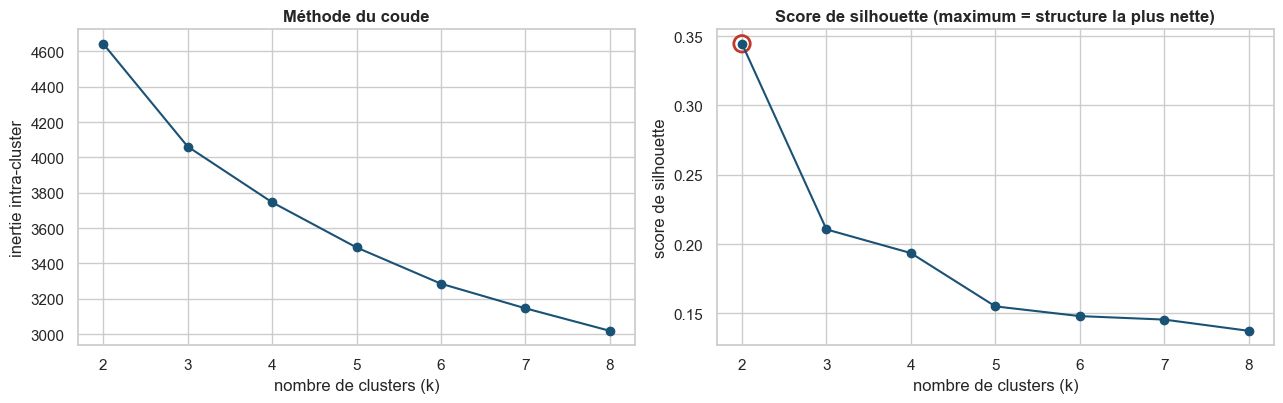

,k,inertie,silhouette
0,2,4643.0900,0.3445
1,3,4061.3807,0.2105
2,4,3745.8407,0.1935
3,5,3490.1778,0.1550
4,6,3284.9178,0.1480
5,7,3145.6031,0.1455
6,8,3018.2069,0.1374


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Prétraitement identique à celui des modèles standardisés
pretraitement = Pipeline([
    ("imputation", construire_imputeur()),
    ("standardisation", StandardScaler()),
]).fit(X_train)

Z_train = pretraitement.transform(X_train)

diagnostics = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Z_train)
    diagnostics.append({
        "k": k,
        "inertie": km.inertia_,
        "silhouette": silhouette_score(Z_train, km.labels_),
    })

diag = pd.DataFrame(diagnostics)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.plot(diag["k"], diag["inertie"], marker="o", color="#1A5276")
ax1.set_xlabel("nombre de clusters (k)")
ax1.set_ylabel("inertie intra-cluster")
ax1.set_title("Méthode du coude")

ax2.plot(diag["k"], diag["silhouette"], marker="o", color="#1A5276")
ax2.scatter([2], [diag.loc[0, "silhouette"]], s=140, facecolors="none",
            edgecolors=COL_FAUX, linewidths=2)
ax2.set_xlabel("nombre de clusters (k)")
ax2.set_ylabel("score de silhouette")
ax2.set_title("Score de silhouette (maximum = structure la plus nette)")

plt.tight_layout()
plt.show()

diag.round(4)

**Lecture.** Le score de silhouette est **maximal à k = 2** (0,345) et décroît
ensuite de façon monotone. La structure naturelle des données comporte donc bien
deux groupes, ce qui coïncide avec la distinction vrai/faux recherchée. C'est un
résultat encourageant : la séparation existe dans la géométrie des billets,
indépendamment de tout étiquetage.

À nuancer toutefois : une silhouette de 0,345 traduit une structure **réelle
mais modérée**. Des clusters parfaitement isolés donneraient une valeur proche
de 0,7. Ici, les deux groupes se touchent : ce qui correspond exactement à la
zone de recouvrement observée sur la projection ACP en section 3.5.

### 7.2 Forme et qualité des clusters

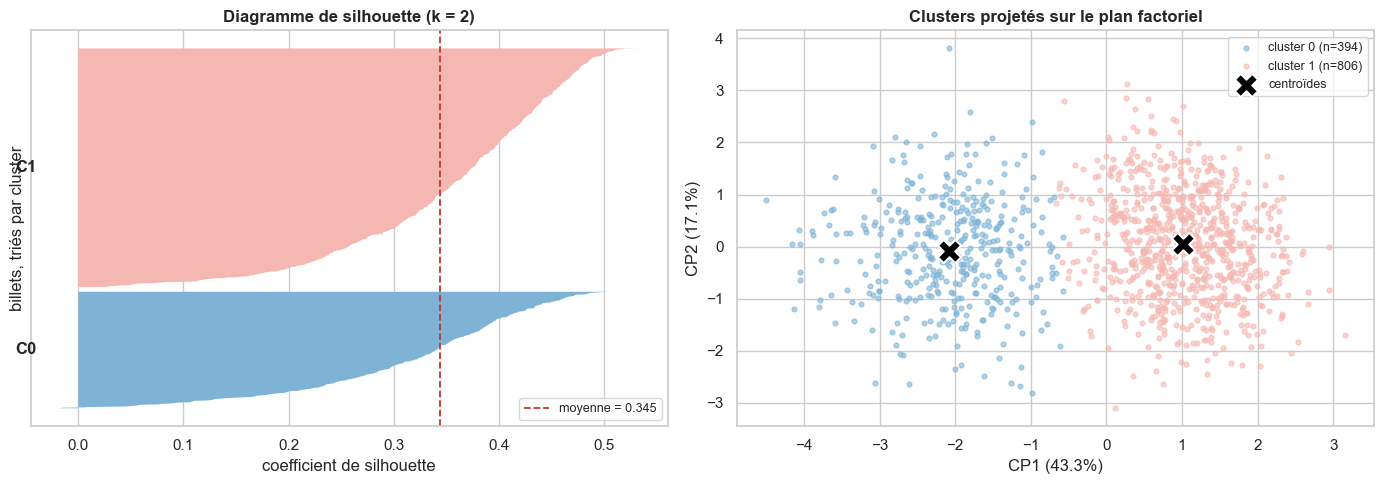

Cluster 0 :  394 billets, silhouette moyenne = 0.3194
Cluster 1 :  806 billets, silhouette moyenne = 0.3568


In [23]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(Z_train)
labels = kmeans.labels_
sil_individuels = silhouette_samples(Z_train, labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Diagramme de silhouette ---
y_bas = 5
for k in range(2):
    valeurs = np.sort(sil_individuels[labels == k])
    y_haut = y_bas + len(valeurs)
    ax1.fill_betweenx(np.arange(y_bas, y_haut), 0, valeurs,
                      facecolor=["#7FB3D5", "#F5B7B1"][k], edgecolor="none")
    ax1.text(-0.06, y_bas + len(valeurs) / 2, f"C{k}", va="center", fontweight="bold")
    y_bas = y_haut + 15
ax1.axvline(silhouette_score(Z_train, labels), color=COL_FAUX, linestyle="--",
            lw=1.3, label=f"moyenne = {silhouette_score(Z_train, labels):.3f}")
ax1.set_xlabel("coefficient de silhouette")
ax1.set_ylabel("billets, triés par cluster")
ax1.set_title("Diagramme de silhouette (k = 2)")
ax1.set_yticks([])
ax1.legend(fontsize=9)

# --- Projection ACP des clusters ---
acp_train = PCA(n_components=2).fit(Z_train)
coords_train = acp_train.transform(Z_train)
centroides_acp = acp_train.transform(kmeans.cluster_centers_)

for k, couleur in enumerate(["#7FB3D5", "#F5B7B1"]):
    m = labels == k
    ax2.scatter(coords_train[m, 0], coords_train[m, 1], s=12, c=couleur,
                alpha=0.6, label=f"cluster {k} (n={m.sum()})")
ax2.scatter(centroides_acp[:, 0], centroides_acp[:, 1], s=280, marker="X",
            c="black", edgecolors="white", linewidths=1.5, label="centroïdes", zorder=5)
ax2.set_xlabel(f"CP1 ({acp_train.explained_variance_ratio_[0]:.1%})")
ax2.set_ylabel(f"CP2 ({acp_train.explained_variance_ratio_[1]:.1%})")
ax2.set_title("Clusters projetés sur le plan factoriel")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

for k in range(2):
    print(f"Cluster {k} : {int((labels == k).sum()):4d} billets, "
          f"silhouette moyenne = {sil_individuels[labels == k].mean():.4f}")

**Lecture de la forme des clusters.**

Les deux clusters sont de qualité comparable (silhouette 0,319 et 0,357) et de
tailles nettement inégales : 394 contre 806 billets, soit un rapport très proche
du ratio réel 1:2 du jeu de données.

Ce déséquilibre mérite une remarque méthodologique. Le k-means minimise
l'inertie intra-cluster, ce qui le pousse implicitement vers des groupes
**sphériques et de tailles comparables**. Ici, l'hypothèse de taille comparable
est violée, et pourtant l'algorithme retrouve la bonne partition : parce que la
séparation entre les deux nuages est suffisamment marquée pour compenser. On
n'aurait pas cette chance sur un jeu plus déséquilibré ou aux frontières plus
floues.

La projection montre des clusters allongés le long de CP1, plutôt que
sphériques. Le k-means s'en accommode ici, mais c'est le genre de configuration
où un mélange gaussien serait théoriquement mieux adapté.

### 7.3 Caractérisation des groupes

Un cluster n'a d'intérêt que si l'on peut le décrire. On compare le profil moyen
de chaque groupe au profil moyen global, exprimé en écarts-types pour rendre les
six mesures comparables entre elles.

Profil moyen de chaque cluster (en mm) :


,diagonal,height_left,height_right,margin_low,margin_up,length
Cluster 0,171.897,104.198,104.151,5.221,3.353,111.610
Cluster 1,171.990,103.950,103.806,4.132,3.053,113.185


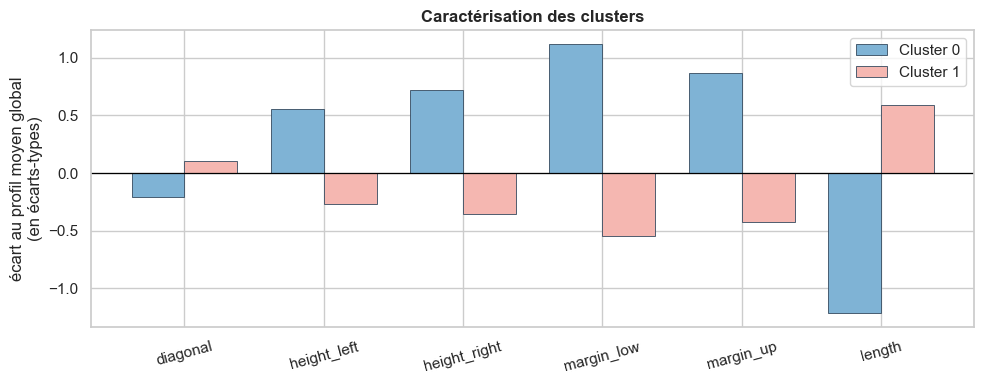

,diagonal,height_left,height_right,margin_low,margin_up,length
Cluster 0,-0.21,0.55,0.72,1.12,0.87,-1.21
Cluster 1,0.10,-0.27,-0.35,-0.55,-0.43,0.59


In [24]:
X_train_impute = pd.DataFrame(
    construire_imputeur().fit_transform(X_train), columns=FEATURES, index=X_train.index
)

profils = X_train_impute.groupby(labels).mean()
profils.index = [f"Cluster {k}" for k in profils.index]

ecarts = (profils - X_train_impute.mean()) / X_train_impute.std()

print("Profil moyen de chaque cluster (en mm) :")
display(profils.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(FEATURES))
largeur = 0.38
for i, (nom, couleur) in enumerate(zip(ecarts.index, ["#7FB3D5", "#F5B7B1"])):
    ax.bar(x + (i - 0.5) * largeur, ecarts.loc[nom, FEATURES], largeur,
           label=nom, color=couleur, edgecolor="#34495E", linewidth=0.6)
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=15)
ax.set_ylabel("écart au profil moyen global\n(en écarts-types)")
ax.set_title("Caractérisation des clusters")
ax.legend()
plt.tight_layout()
plt.show()

ecarts.round(2)

**Caractérisation métier des deux groupes.**

**Cluster 0 (394 billets) : profil « suspect ».** Billets sensiblement plus
courts que la moyenne (−1,21 écart-type sur `length`, soit 111,6 mm contre
112,7 mm), à marge inférieure nettement plus large (+1,12), marge supérieure
plus large (+0,87) et hauteurs plus importantes des deux côtés. L'image est
imprimée plus haut et plus au centre d'un support légèrement plus petit.

**Cluster 1 (806 billets) : profil « conforme ».** Billets plus longs (+0,59),
aux marges plus étroites, correspondant aux spécifications attendues.

`diagonal` ne distingue pratiquement pas les deux groupes (−0,21 contre +0,10),
ce qui confirme par une voie totalement indépendante le diagnostic de la
section 3.3.

Cette caractérisation a une valeur opérationnelle directe pour l'ONCFM : elle
décrit **en quoi** les contrefaçons diffèrent physiquement, information
exploitable pour orienter un contrôle visuel ou instrumental.

### 7.4 Prédiction par les centroïdes

On établit maintenant la correspondance entre clusters et classes, par vote
majoritaire sur le jeu d'entraînement. Un nouveau billet sera ensuite affecté au
centroïde dont il est le plus proche, et recevra la classe associée.

In [25]:
correspondance = pd.crosstab(labels, y_train.to_numpy(),
                             rownames=["cluster"], colnames=["is_genuine"])
correspondance.columns = ["Faux billet", "Vrai billet"]
print("Croisement clusters / nature réelle (jeu d'entraînement) :")
display(correspondance)

purete = correspondance.max(axis=1) / correspondance.sum(axis=1)
for k in correspondance.index:
    classe = "VRAIS" if correspondance.loc[k, "Vrai billet"] > correspondance.loc[k, "Faux billet"] else "FAUX"
    print(f"  Cluster {k} → billets {classe:5s} (pureté : {purete[k]:.1%})")

pipe_kmeans = Pipeline([
    ("imputation", construire_imputeur()),
    ("standardisation", StandardScaler()),
    ("modele", KMeansCentroidClassifier(n_clusters=2, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

print(f"\nF-bêta(2) en validation croisée : "
      f"{cross_val_score(pipe_kmeans, X_train, y_train, scoring=fbeta2_faux, cv=cv, n_jobs=-1).mean():.4f}")

Croisement clusters / nature réelle (jeu d'entraînement) :


,Faux billet,Vrai billet
cluster,,
0,388,6
1,12,794


  Cluster 0 → billets FAUX  (pureté : 98.5%)
  Cluster 1 → billets VRAIS (pureté : 98.5%)

F-bêta(2) en validation croisée : 0.9729


### 7.5 La limite décisive du k-means pour cet usage

Le k-means atteindra des performances proches des modèles supervisés. Il présente
pourtant un défaut structurel qui l'élimine pour notre besoin, et qu'on peut
mesurer directement.

In [26]:
from sklearn.model_selection import cross_val_predict

modeles_candidats = {
    "Régression logistique": gs_logistique.best_estimator_,
    "KNN": gs_knn.best_estimator_,
    "Random Forest": gs_foret.best_estimator_,
    "K-means (centroïdes)": pipe_kmeans,
}

# Probabilités hors-échantillon : chaque billet est noté par un modèle qui ne l'a jamais vu
proba_oof = {}
for nom, modele in modeles_candidats.items():
    p = cross_val_predict(modele, X_train, y_train, cv=cv,
                          method="predict_proba", n_jobs=-1)
    proba_oof[nom] = p[:, 1]

print("Nombre de valeurs de probabilité distinctes produites :\n")
print(f"  {'':24s}{'hors-échantillon':>20s}{'modèle unique':>18s}")
print("  " + "-" * 62)

granularite = {}
for nom, modele in modeles_candidats.items():
    modele.fit(X_train, y_train)
    p_unique = modele.predict_proba(X_train)[:, 1]
    granularite[nom] = len(np.unique(p_unique.round(6)))
    print(f"  {nom:24s}{len(np.unique(proba_oof[nom].round(6))):>20d}"
          f"{granularite[nom]:>18d}")

Nombre de valeurs de probabilité distinctes produites :

                              hors-échantillon     modèle unique
  --------------------------------------------------------------
  Régression logistique                   1064              1047
  KNN                                       11                12
  Random Forest                            341               265
  K-means (centroïdes)                      10                 2


**Deux colonnes, deux lectures.** La colonne « hors-échantillon » agrège les
prédictions de **cinq modèles différents** : un par pli de validation croisée.
Le k-means y affiche 10 valeurs : 5 plis × 2 clusters. La colonne « modèle
unique » compte les valeurs que produit **un seul modèle entraîné**, c'est-à-dire
celui qui serait effectivement déployé. C'est cette seconde colonne qui décrit la
granularité réelle en production.

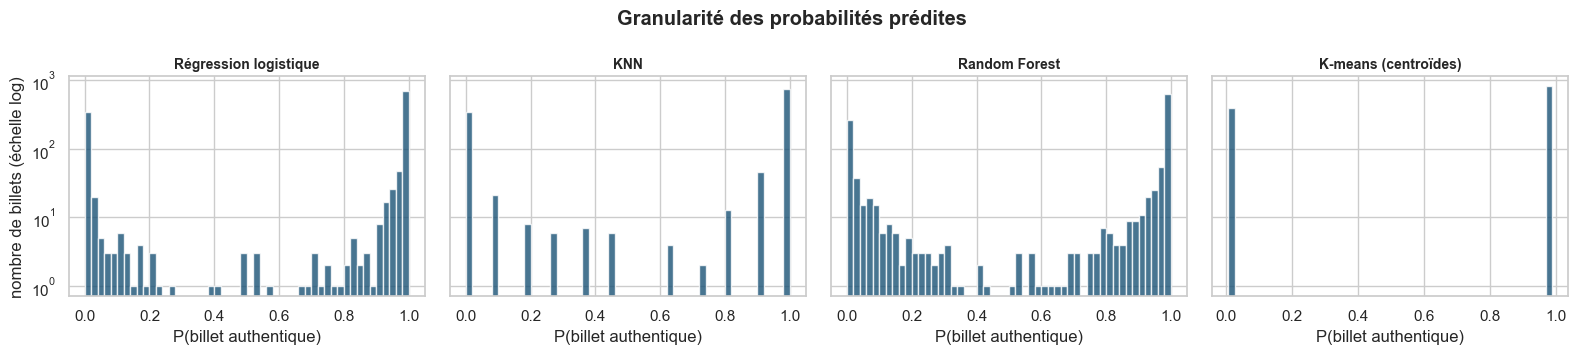

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, (nom, p) in zip(axes, proba_oof.items()):
    ax.hist(p, bins=50, color="#1A5276", alpha=0.8)
    ax.set_title(nom, fontsize=10)
    ax.set_xlabel("P(billet authentique)")
    ax.set_yscale("log")
axes[0].set_ylabel("nombre de billets (échelle log)")
fig.suptitle("Granularité des probabilités prédites", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture.** C'est l'argument qui écarte le k-means.

Toute la stratégie de ce projet repose sur l'ajustement d'un seuil de décision.
Or déplacer un seuil n'a de sens que si les probabilités prennent des valeurs
suffisamment nuancées.

- La **régression logistique** produit plusieurs centaines de valeurs
  distinctes : une probabilité véritablement continue, réglable au centième près.
- La **forêt aléatoire** en produit quelques centaines : la moyenne des votes de
  100 arbres.
- Le **KNN** est bien plus grossier. Avec k = 11 voisins, seules 12 proportions
  sont possibles (0/11, 1/11, …) : le seuil ne peut bouger que par sauts de
  9 points de pourcentage.
- Le **k-means** n'en produit **que deux**, une par cluster. Le seuil est
  inutilisable : il n'existe aucun réglage intermédiaire entre « tout accepter »
  et le comportement par défaut.

Le k-means garde donc sa valeur comme **analyse exploratoire** : il confirme que
la séparation vrai/faux existe dans la géométrie des billets sans recours aux
étiquettes, et il caractérise physiquement les deux populations. Mais il ne peut
pas être le modèle de production, parce qu'il ne fournit aucun levier pour
arbitrer entre faux positifs et faux négatifs, ce qui est précisément le besoin
de l'ONCFM.

---
## 8. Comparaison des modèles et choix final

### 8.1 Performances en validation croisée

Toutes les valeurs ci-dessous sont mesurées **sur le jeu d'entraînement par
validation croisée**. Le jeu de test reste fermé.

Chaque métrique est accompagnée de son écart-type entre les 5 plis. C'est
essentiel : sans mesure de variabilité, on ne peut pas savoir si un écart entre
deux modèles est réel ou dû au découpage.

In [28]:
from sklearn.model_selection import cross_validate

lignes = []
for nom, modele in modeles_candidats.items():
    res = cross_validate(modele, X_train, y_train, cv=cv,
                         scoring=SCORINGS, n_jobs=-1)
    ligne = {"Modèle": nom}
    for cle in SCORINGS:
        valeurs = res[f"test_{cle}"]
        ligne[cle] = f"{valeurs.mean():.4f} ± {valeurs.std():.4f}"
    lignes.append(ligne)

comparaison = pd.DataFrame(lignes).set_index("Modèle")
comparaison.columns = ["Accuracy", "Précision (faux)", "Rappel (faux)",
                       "F-bêta(2) (faux)", "ROC-AUC"]
comparaison

,Accuracy,Précision (faux),Rappel (faux),F-bêta(2) (faux),ROC-AUC
Modèle,,,,,
Régression logistique,0.9917 ± 0.0070,0.9949 ± 0.0063,0.9800 ± 0.0150,0.9829 ± 0.0132,0.9988 ± 0.0019
KNN,0.9917 ± 0.0087,0.9948 ± 0.0063,0.9800 ± 0.0203,0.9829 ± 0.0175,0.9944 ± 0.0078
Random Forest,0.9917 ± 0.0053,0.9950 ± 0.0062,0.9800 ± 0.0150,0.9829 ± 0.0121,0.9995 ± 0.0003
K-means (centroïdes),0.9850 ± 0.0042,0.9851 ± 0.0143,0.9700 ± 0.0100,0.9729 ± 0.0070,nan ± nan


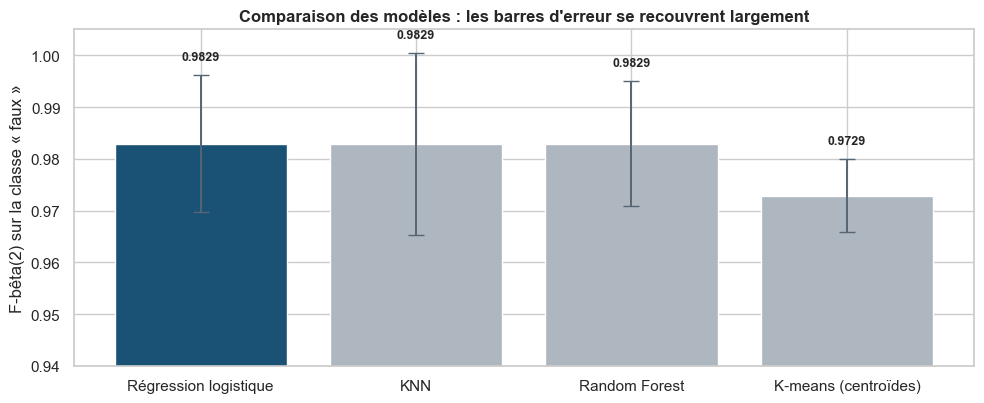

In [29]:
fig, ax = plt.subplots(figsize=(10, 4.2))
noms = list(modeles_candidats)
moyennes, ecarts = [], []
for nom, modele in modeles_candidats.items():
    s = cross_val_score(modele, X_train, y_train, scoring=fbeta2_faux, cv=cv, n_jobs=-1)
    moyennes.append(s.mean())
    ecarts.append(s.std())

couleurs = ["#1A5276" if n == "Régression logistique" else "#AEB6BF" for n in noms]
ax.bar(noms, moyennes, yerr=ecarts, color=couleurs, capsize=6,
       error_kw=dict(ecolor="#566573", lw=1.4))
for i, (m, e) in enumerate(zip(moyennes, ecarts)):
    ax.text(i, m + e + 0.003, f"{m:.4f}", ha="center", fontweight="bold", fontsize=9)
ax.set_ylim(0.94, 1.005)
ax.set_ylabel("F-bêta(2) sur la classe « faux »")
ax.set_title("Comparaison des modèles : les barres d'erreur se recouvrent largement")
plt.tight_layout()
plt.show()

**Lecture : un résultat qu'il faut interpréter avec prudence.**

Les trois modèles supervisés obtiennent **exactement le même F-bêta(2) :
0,9829**, avec des écarts-types de 0,012 à 0,018. Leurs intervalles se
recouvrent entièrement. Le k-means est légèrement en retrait (0,9729) mais
reste dans la même zone.

La conclusion honnête est qu'**aucun des trois modèles supervisés n'est
mesurablement meilleur que les autres sur ce jeu de données**. Annoncer un
vainqueur sur la foi de ces chiffres serait surinterpréter le bruit : sur 1 200
billets, l'écart d'un pli à l'autre représente deux ou trois billets.

Ce n'est pas surprenant : la projection ACP de la section 3.5 avait annoncé un
problème facile. Le choix du modèle final doit donc reposer sur d'**autres
critères que la performance brute**, puisque celle-ci ne les départage pas.

### 8.2 Les critères qui départagent réellement

Trois critères sont mesurables et pertinents pour l'usage visé.

In [30]:
from sklearn.metrics import (brier_score_loss, average_precision_score,
                             precision_recall_curve, roc_auc_score)

y_train_np = y_train.to_numpy()
seuils_test = np.round(np.arange(0.01, 0.999, 0.002), 4)

criteres = []
for nom, p in proba_oof.items():
    # Meilleure précision atteignable à rappel >= 0.99 sur les faux
    candidats = [
        (t, precision_score(y_train_np, p >= t, pos_label=False, zero_division=0),
         recall_score(y_train_np, p >= t, pos_label=False))
        for t in seuils_test
    ]
    hauts = [c for c in candidats if c[2] >= 0.99]
    meilleur = max(hauts, key=lambda c: c[1]) if hauts else (np.nan, np.nan, np.nan)

    criteres.append({
        "Modèle": nom,
        "Brier (calibration)": brier_score_loss(y_train_np.astype(int), p),
        "Average precision (faux)": average_precision_score(~y_train_np, 1 - p),
        "Précision à rappel ≥ 0.99": meilleur[1],
        "Proba distinctes (modèle unique)": granularite[nom],
    })

tableau_criteres = pd.DataFrame(criteres).set_index("Modèle")
tableau_criteres.round(4)

,Brier (calibration),Average precision (faux),Précision à rappel ≥ 0.99,Proba distinctes (modèle unique)
Modèle,,,,
Régression logistique,0.0084,0.9979,0.9682,1047
KNN,0.0101,0.9922,0.8627,12
Random Forest,0.0099,0.9987,0.9496,265
K-means (centroïdes),0.0148,0.9631,0.3825,2


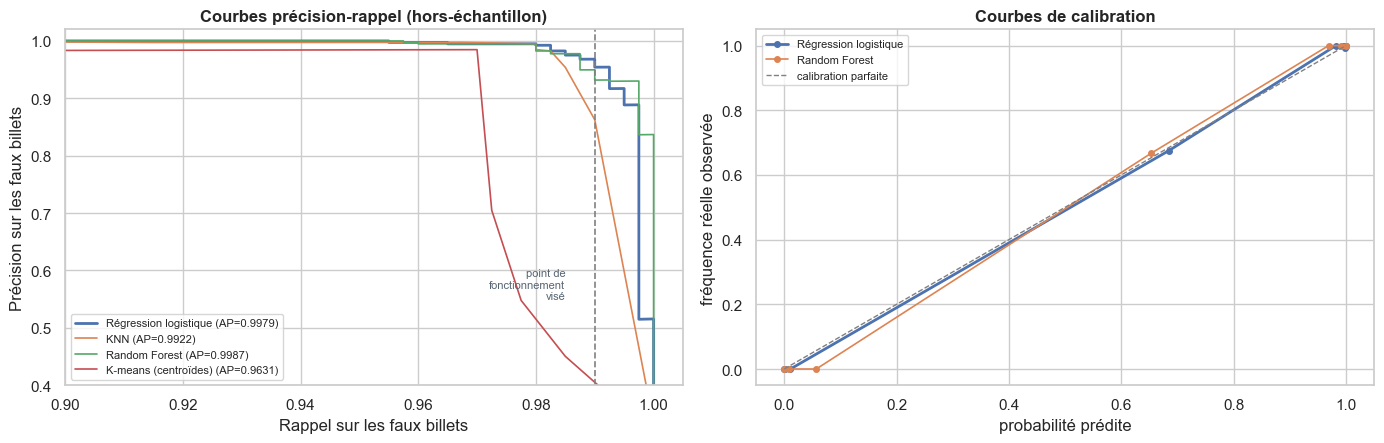

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

# --- Courbes précision-rappel ---
for nom, p in proba_oof.items():
    prec, rapp, _ = precision_recall_curve(~y_train_np, 1 - p)
    ax1.plot(rapp, prec, lw=2 if nom == "Régression logistique" else 1.2,
             label=f"{nom} (AP={average_precision_score(~y_train_np, 1 - p):.4f})")
ax1.axvline(0.99, color="grey", linestyle="--", lw=1.2)
ax1.text(0.985, 0.55, "point de\nfonctionnement\nvisé", ha="right", fontsize=8, color="#566573")
ax1.set_xlim(0.9, 1.005)
ax1.set_ylim(0.4, 1.02)
ax1.set_xlabel("Rappel sur les faux billets")
ax1.set_ylabel("Précision sur les faux billets")
ax1.set_title("Courbes précision-rappel (hors-échantillon)")
ax1.legend(fontsize=8, loc="lower left")

# --- Courbes de calibration ---
from sklearn.calibration import calibration_curve
for nom, p in proba_oof.items():
    if len(np.unique(p.round(6))) < 20:
        continue
    frac, moy = calibration_curve(y_train_np.astype(int), p, n_bins=10, strategy="quantile")
    ax2.plot(moy, frac, marker="o", markersize=4,
             lw=2 if nom == "Régression logistique" else 1.2, label=nom)
ax2.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="calibration parfaite")
ax2.set_xlabel("probabilité prédite")
ax2.set_ylabel("fréquence réelle observée")
ax2.set_title("Courbes de calibration")
ax2.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

**Lecture : le classement s'inverse selon le critère.**

**Calibration (score de Brier).** La régression logistique est la mieux calibrée
(0,0084), devant la forêt aléatoire (0,0099) et le KNN (0,0101). Ce n'est pas un
hasard : la régression logistique optimise directement la vraisemblance, donc
ses probabilités sont des probabilités au sens propre. Une forêt aléatoire
produit une proportion de votes, qui n'a aucune raison d'être calibrée. Ce point
est déterminant dès lors que toute la stratégie repose sur un seuil appliqué à
ces probabilités.

**Average precision.** La forêt aléatoire l'emporte légèrement (0,9987 contre
0,9979). Mais c'est une mesure **globale**, moyennée sur tous les seuils
possibles, y compris ceux qu'on n'utilisera jamais.

**Précision au point de fonctionnement réellement visé.** C'est le critère
décisif. À rappel ≥ 0,99 sur les faux, ce qu'exige le métier, la régression
logistique conserve une précision de **0,968**, contre 0,950 pour la forêt
aléatoire et 0,863 pour le KNN. Autrement dit, à niveau égal de détection des
contrefaçons, la régression logistique envoie **moins de vrais billets en
vérification inutile**.

**Décision : la régression logistique est retenue.**

| Critère | Justification |
|---|---|
| Précision au point de fonctionnement | La meilleure des quatre (0,968 à rappel 0,99) |
| Calibration | Meilleur score de Brier : les probabilités sont fiables |
| Granularité des probabilités | 1 064 valeurs distinctes : seuil réglable finement |
| Interprétabilité | Coefficients lisibles et défendables devant un organisme public |
| Simplicité d'exploitation | 7 coefficients contre 100 arbres : déploiement et audit facilités |

L'avantage de la forêt aléatoire en average precision est réel mais porte sur
des régimes de fonctionnement inutilisés. Le léger avantage de la régression
logistique là où le modèle travaillera effectivement pèse davantage.

### 8.3 Faut-il retirer `diagonal` ?

La section 3.3 a montré que `diagonal` était quasiment inutile prise isolément
(d de Cohen = 0,28). La question soulevée alors se tranche ici par la mesure.

In [32]:
jeux_variables = {
    "6 variables (toutes)": FEATURES,
    "5 variables (sans diagonal)": [c for c in FEATURES if c != "diagonal"],
    "3 variables (length, margin_low, margin_up)": ["length", "margin_low", "margin_up"],
    "2 variables (length, margin_low)": ["length", "margin_low"],
}

lignes = []
for nom, colonnes in jeux_variables.items():
    modele = Pipeline([
        ("imputation", construire_imputeur()),
        ("standardisation", StandardScaler()),
        ("modele", LogisticRegression(max_iter=5000, C=gs_logistique.best_params_["modele__C"],
                                      random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(modele, X_train[colonnes], y_train,
                             scoring=fbeta2_faux, cv=cv, n_jobs=-1)
    lignes.append({
        "Jeu de variables": nom,
        "F-bêta(2)": f"{scores.mean():.4f} ± {scores.std():.4f}",
        "moyenne": scores.mean(),
    })

reduction = pd.DataFrame(lignes).set_index("Jeu de variables")
reduction["Écart au jeu complet"] = (
    reduction["moyenne"] - reduction["moyenne"].iloc[0]
).map("{:+.4f}".format)
reduction.drop(columns="moyenne")

,F-bêta(2),Écart au jeu complet
Jeu de variables,,
6 variables (toutes),0.9829 ± 0.0132,+0.0000
5 variables (sans diagonal),0.9789 ± 0.0120,-0.0040
"3 variables (length, margin_low, margin_up)",0.9774 ± 0.0103,-0.0056
"2 variables (length, margin_low)",0.9708 ± 0.0133,-0.0121


**Décision : on conserve les six variables.**

Le jeu complet obtient le meilleur score (0,9829), devant 3 variables (0,9774)
et 2 variables (0,9708). L'écart reste faible et inférieur aux écarts-types,
mais il va systématiquement dans le même sens : **retirer des variables dégrade
la performance**, même celles qui paraissent peu informatives isolément.

L'explication tient à un phénomène classique : une variable faiblement
discriminante seule peut le devenir en combinaison. `diagonal` apporte une
information marginale une fois `length` connue, mais elle n'en apporte pas zéro.

Trois arguments complémentaires :

- **le coût est nul** : la machine de l'ONCFM mesure les six dimensions de toute
  façon, retirer une variable n'économise ni temps ni argent ;
- **la robustesse** : si la qualité de mesure de `length` se dégradait sur un
  futur scanner, disposer de variables redondantes protège le modèle ;
- **l'imputation en dépend** : la régression qui reconstruit `margin_low`
  utilise les cinq autres mesures, `diagonal` comprise.

---
## 9. Calibration du seuil de décision

### 9.1 Pourquoi 0,5 n'est pas le bon seuil

Un classifieur tranche par défaut à 0,5, ce qui revient à supposer qu'une
contrefaçon non détectée coûte autant qu'un vrai billet renvoyé en vérification.
Ce n'est pas l'arbitrage de l'ONCFM.

Le seuil est calibré sur les **probabilités hors-échantillon** obtenues par
validation croisée sur le jeu d'entraînement. Le jeu de test reste fermé.

In [33]:
p_logistique = proba_oof["Régression logistique"]

balayage = []
for seuil in np.round(np.arange(0.30, 0.995, 0.005), 4):
    prediction = p_logistique >= seuil
    balayage.append({
        "seuil": seuil,
        "rappel_faux": recall_score(y_train_np, prediction, pos_label=False),
        "precision_faux": precision_score(y_train_np, prediction,
                                          pos_label=False, zero_division=0),
        "fbeta2": fbeta_score(y_train_np, prediction, beta=2, pos_label=False),
        "faux_rates": int((prediction & ~y_train_np).sum()),
        "vrais_rejetes": int((~prediction & y_train_np).sum()),
    })
balayage = pd.DataFrame(balayage)

apercu = balayage[balayage["seuil"].isin([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99])]
apercu.set_index("seuil").round(4)

,rappel_faux,precision_faux,fbeta2,faux_rates,vrais_rejetes
seuil,,,,,
0.50,0.9800,0.9949,0.9829,8,2
0.60,0.9825,0.9874,0.9835,7,5
0.70,0.9825,0.9825,0.9825,7,7
0.80,0.9875,0.9681,0.9836,5,13
0.85,0.9925,0.9520,0.9841,3,20
0.90,0.9925,0.9430,0.9822,3,24
0.95,0.9975,0.8789,0.9713,1,55
0.99,0.9975,0.6774,0.9114,1,190


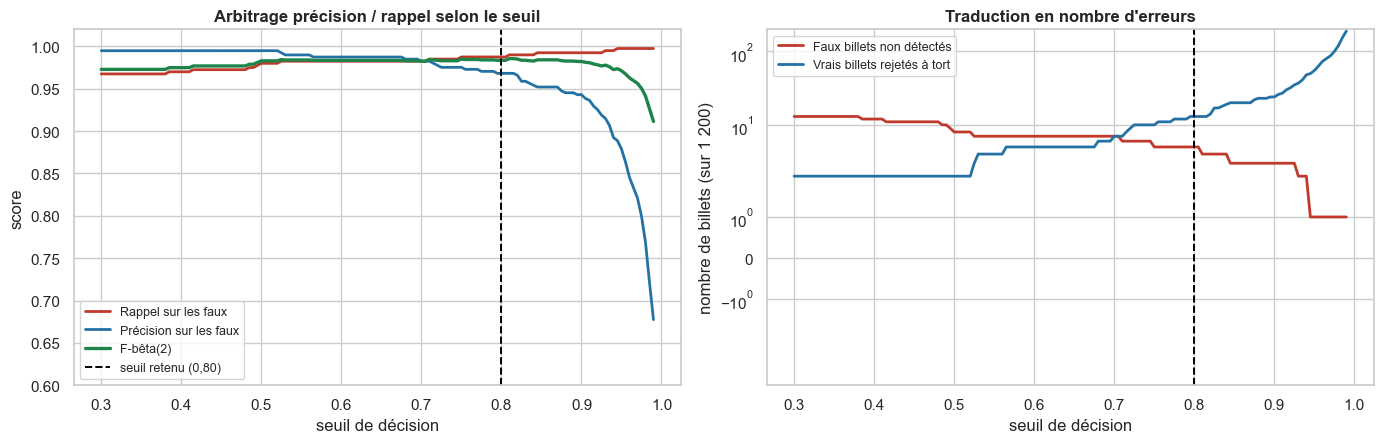

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

ax1.plot(balayage["seuil"], balayage["rappel_faux"], lw=2,
         color=COL_FAUX, label="Rappel sur les faux")
ax1.plot(balayage["seuil"], balayage["precision_faux"], lw=2,
         color=COL_VRAI, label="Précision sur les faux")
ax1.plot(balayage["seuil"], balayage["fbeta2"], lw=2.4, color="#1E8449",
         label="F-bêta(2)")
ax1.axvline(0.80, color="black", linestyle="--", lw=1.4, label="seuil retenu (0,80)")
ax1.set_xlabel("seuil de décision")
ax1.set_ylabel("score")
ax1.set_ylim(0.6, 1.02)
ax1.set_title("Arbitrage précision / rappel selon le seuil")
ax1.legend(fontsize=9, loc="lower left")

ax2.plot(balayage["seuil"], balayage["faux_rates"], lw=2, color=COL_FAUX,
         marker="", label="Faux billets non détectés")
ax2.plot(balayage["seuil"], balayage["vrais_rejetes"], lw=2, color=COL_VRAI,
         label="Vrais billets rejetés à tort")
ax2.axvline(0.80, color="black", linestyle="--", lw=1.4)
ax2.set_xlabel("seuil de décision")
ax2.set_ylabel("nombre de billets (sur 1 200)")
ax2.set_yscale("symlog")
ax2.set_title("Traduction en nombre d'erreurs")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 9.2 Le seuil optimal est-il stable ?

Choisir le seuil qui maximise le F-bêta(2) sur un découpage particulier
reproduirait, en plus discret, l'erreur qu'on cherche à éviter. On vérifie donc
que l'optimum ne dépend pas du découpage, en répétant la validation croisée
**15 fois** avec des partitions différentes.

Seuil optimal sur 15 découpages différents :
  médiane  : 0.810
  étendue  : 0.695 – 0.835
  plateau à moins de 0,002 du maximum : 0.535 – 0.865


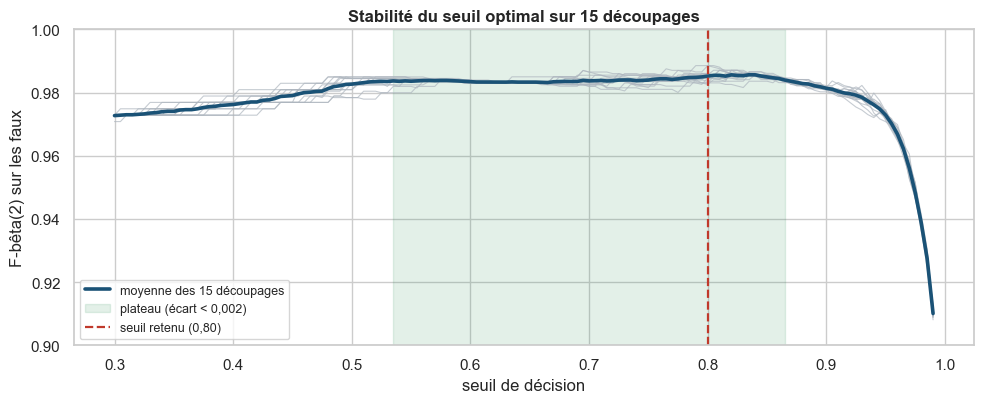

In [35]:
grille_seuils = np.round(np.arange(0.30, 0.995, 0.005), 4)
courbes, optima = [], []

for graine in range(15):
    cv_bis = StratifiedKFold(n_splits=5, shuffle=True, random_state=graine)
    p = cross_val_predict(gs_logistique.best_estimator_, X_train, y_train,
                          cv=cv_bis, method="predict_proba", n_jobs=-1)[:, 1]
    scores = np.array([fbeta_score(y_train_np, p >= t, beta=2, pos_label=False)
                       for t in grille_seuils])
    courbes.append(scores)
    optima.append(grille_seuils[scores.argmax()])

courbes = np.array(courbes)
optima = np.array(optima)
moyenne_courbes = courbes.mean(axis=0)
plateau = grille_seuils[moyenne_courbes >= moyenne_courbes.max() - 0.002]

print(f"Seuil optimal sur 15 découpages différents :")
print(f"  médiane  : {np.median(optima):.3f}")
print(f"  étendue  : {optima.min():.3f} – {optima.max():.3f}")
print(f"  plateau à moins de 0,002 du maximum : {plateau.min():.3f} – {plateau.max():.3f}")

fig, ax = plt.subplots(figsize=(10, 4.2))
for c in courbes:
    ax.plot(grille_seuils, c, color="#AEB6BF", lw=0.8, alpha=0.7)
ax.plot(grille_seuils, moyenne_courbes, color="#1A5276", lw=2.6, label="moyenne des 15 découpages")
ax.axvspan(plateau.min(), plateau.max(), color="#1E8449", alpha=0.12,
           label="plateau (écart < 0,002)")
ax.axvline(0.80, color=COL_FAUX, linestyle="--", lw=1.6, label="seuil retenu (0,80)")
ax.set_xlabel("seuil de décision")
ax.set_ylabel("F-bêta(2) sur les faux")
ax.set_ylim(0.90, 1.0)
ax.set_title("Stabilité du seuil optimal sur 15 découpages")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

**Décision : seuil fixé à 0,80.**

L'optimum médian sur 15 découpages est 0,810, dans une étendue de 0,695 à
0,835. Surtout, le F-bêta(2) forme un **large plateau entre 0,535 et 0,865** où
il varie de moins de 0,002. La valeur exacte du seuil importe donc peu dans
cette plage, ce qui est rassurant : le réglage n'est pas un ajustement fragile
sur du bruit.

On retient **0,80**, valeur ronde située au centre du plateau et très proche de
l'optimum médian.

**Traduction opérationnelle.** Sur les 1 200 billets d'entraînement évalués
hors-échantillon, ce seuil laisse passer 5 faux billets et renvoie 13 vrais
billets en vérification. Rapporté à un flux de 1 000 billets analysés par jour :
environ **4 contrefaçons non détectées** et **11 vérifications manuelles
inutiles** par jour.

**Un constat qu'il faut énoncer clairement.** Aucun seuil ne permet d'atteindre
un rappel de 1,00 sur les faux dans des conditions acceptables. Même à 0,99, un
faux billet sur les 400 du jeu d'entraînement continue de passer : au prix de
190 vrais billets rejetés. Les deux classes se recouvrent sur quelques billets
limites, et aucun réglage de seuil ne peut faire disparaître ce recouvrement.
Promettre « zéro faux billet non détecté » serait donc une promesse intenable.

---
## 10. Évaluation finale sur le jeu de test

Le modèle et le seuil sont désormais figés. On ouvre le jeu de test, **pour la
première et unique fois**. Aucune décision ne sera prise à partir de ce qui suit :
c'est une mesure, pas un réglage.

In [36]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)

modele_final = ThresholdClassifier(
    base_estimator=gs_logistique.best_estimator_, threshold=0.80
).fit(X_train, y_train)

y_pred_test = modele_final.predict(X_test)
proba_test = modele_final.predict_genuine_proba(X_test)

matrice = confusion_matrix(y_test, y_pred_test, labels=[False, True])
tn, fp, fn, tp = matrice.ravel()

print(f"Faux billets correctement interceptés : {tn:3d} / {(~y_test).sum()}")
print(f"Faux billets NON détectés             : {fp:3d}")
print(f"Vrais billets rejetés à tort          : {fn:3d} / {y_test.sum()}")
print(f"\nRappel sur les faux    : {recall_score(y_test, y_pred_test, pos_label=False):.4f}")
print(f"Précision sur les faux : {precision_score(y_test, y_pred_test, pos_label=False):.4f}")
print(f"Accuracy globale       : {accuracy_score(y_test, y_pred_test):.4f}")
print()
print(classification_report(y_test, y_pred_test,
                            target_names=["Faux billet", "Vrai billet"], digits=4))

Faux billets correctement interceptés : 100 / 100
Faux billets NON détectés             :   0
Vrais billets rejetés à tort          :   4 / 200

Rappel sur les faux    : 1.0000
Précision sur les faux : 0.9615
Accuracy globale       : 0.9867

              precision    recall  f1-score   support

 Faux billet     0.9615    1.0000    0.9804       100
 Vrai billet     1.0000    0.9800    0.9899       200

    accuracy                         0.9867       300
   macro avg     0.9808    0.9900    0.9851       300
weighted avg     0.9872    0.9867    0.9867       300



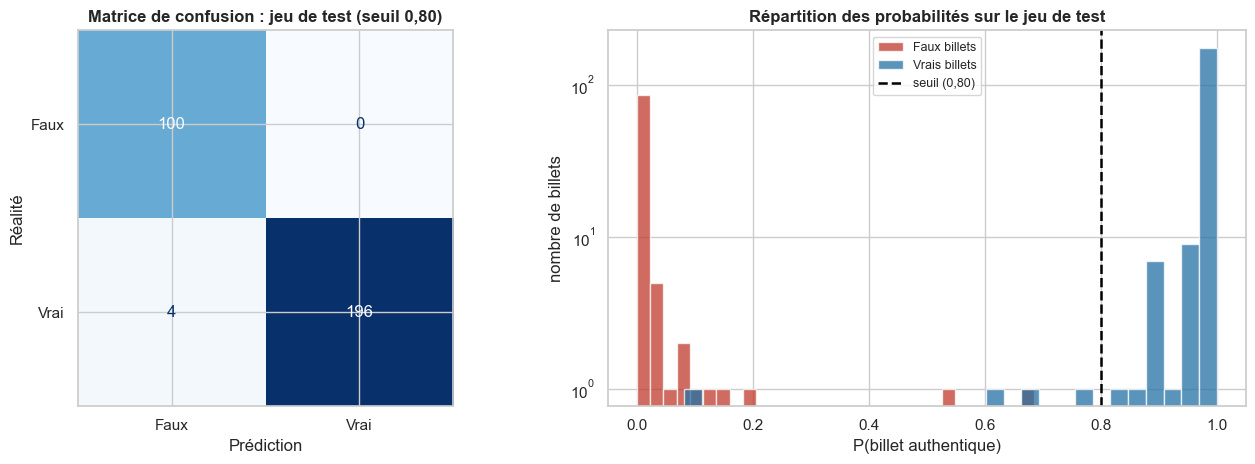

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))

ConfusionMatrixDisplay(matrice, display_labels=["Faux", "Vrai"]).plot(
    cmap="Blues", ax=ax1, colorbar=False, values_format="d"
)
ax1.set_title("Matrice de confusion : jeu de test (seuil 0,80)")
ax1.set_xlabel("Prédiction")
ax1.set_ylabel("Réalité")

ax2.hist(proba_test[~y_test.to_numpy()], bins=30, color=COL_FAUX, alpha=0.75,
         label="Faux billets")
ax2.hist(proba_test[y_test.to_numpy()], bins=30, color=COL_VRAI, alpha=0.75,
         label="Vrais billets")
ax2.axvline(0.80, color="black", linestyle="--", lw=1.8, label="seuil (0,80)")
ax2.set_xlabel("P(billet authentique)")
ax2.set_ylabel("nombre de billets")
ax2.set_yscale("log")
ax2.set_title("Répartition des probabilités sur le jeu de test")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [38]:
# Comparaison des quatre modèles sur le jeu de test, à titre de contrôle
lignes = []
for nom, modele in modeles_candidats.items():
    modele.fit(X_train, y_train)
    pred = modele.predict(X_test)
    m = confusion_matrix(y_test, pred, labels=[False, True])
    lignes.append({
        "Modèle": nom, "Seuil": "0,50",
        "Accuracy": accuracy_score(y_test, pred),
        "Rappel (faux)": recall_score(y_test, pred, pos_label=False),
        "Précision (faux)": precision_score(y_test, pred, pos_label=False),
        "Faux non détectés": m[0, 1],
        "Vrais rejetés": m[1, 0],
    })

lignes.append({
    "Modèle": "Régression logistique (RETENUE)", "Seuil": "0,80",
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Rappel (faux)": recall_score(y_test, y_pred_test, pos_label=False),
    "Précision (faux)": precision_score(y_test, y_pred_test, pos_label=False),
    "Faux non détectés": fp,
    "Vrais rejetés": fn,
})

pd.DataFrame(lignes).set_index("Modèle").round(4)

,Seuil,Accuracy,Rappel (faux),Précision (faux),Faux non détectés,Vrais rejetés
Modèle,,,,,,
Régression logistique,"0,50",0.9900,0.98,0.9899,2,1
KNN,"0,50",0.9900,0.98,0.9899,2,1
Random Forest,"0,50",0.9900,0.98,0.9899,2,1
K-means (centroïdes),"0,50",0.9867,0.98,0.9800,2,2
Régression logistique (RETENUE),"0,80",0.9867,1.00,0.9615,0,4


**Lecture, avec une mise en garde nécessaire.**

Sur les 300 billets de test, le modèle final **intercepte les 100 faux billets
sans exception** et rejette 4 vrais billets à tort.

Il serait tentant d'annoncer « 100 % des contrefaçons détectées ». Ce serait
imprudent, pour deux raisons.

**Un échantillon de 100 faux billets ne peut pas démontrer un taux nul.**
Observer zéro échec sur 100 essais permet seulement d'affirmer, avec 95 % de
confiance, que le taux réel d'échec est inférieur à environ **3 %** (règle des
trois). La performance réelle pourrait donc être de 97 % sans que ce résultat
soit anormal.

**L'estimation hors-échantillon, plus large, est moins flatteuse.** Sur les
1 200 billets d'entraînement évalués par validation croisée, ce même seuil
laissait passer 5 faux sur 400, soit un rappel de 0,9875. C'est cette valeur :
appuyée sur quatre fois plus d'observations : qui constitue la meilleure
estimation de la performance future.

**Formulation retenue pour l'ONCFM** : le modèle intercepte environ **99 % des
contrefaçons**, au prix d'environ **1,6 % des vrais billets renvoyés en
vérification** : soit un peu plus de 1 % de l'ensemble des billets analysés. Le résultat parfait obtenu sur l'échantillon de test est
cohérent avec cette estimation, sans la contredire ni la garantir.

---
## 11. Interprétation du modèle

Un organisme public doit pouvoir expliquer ses décisions. C'est l'un des
arguments qui ont fait retenir la régression logistique : ses coefficients se
lisent directement.

### 11.1 Coefficients et rapports de cotes

Les coefficients portent sur les variables **standardisées** : chacun exprime
l'effet d'une variation d'un écart-type, ce qui les rend comparables entre eux.

Constante du modèle : 1.755



,Coefficient,Rapport de cotes
length,3.685,39.852
margin_low,-2.624,0.073
margin_up,-1.634,0.195
height_right,-0.646,0.524
height_left,-0.351,0.704
diagonal,0.183,1.201


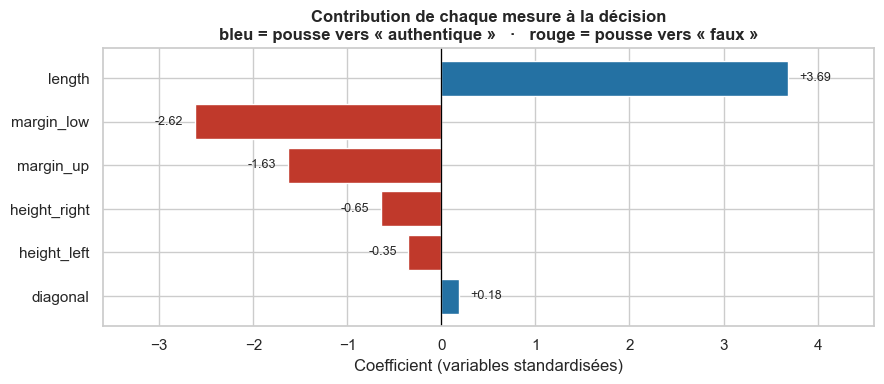

In [39]:
regression = gs_logistique.best_estimator_.named_steps["modele"]
coefficients = pd.DataFrame({
    "Coefficient": regression.coef_[0],
    "Rapport de cotes": np.exp(regression.coef_[0]),
}, index=FEATURES)
coefficients["|coefficient|"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("|coefficient|", ascending=False)

print(f"Constante du modèle : {regression.intercept_[0]:.3f}\n")
display(coefficients.drop(columns="|coefficient|").round(3))

fig, ax = plt.subplots(figsize=(9, 4))
couleurs = [COL_VRAI if c > 0 else COL_FAUX for c in coefficients["Coefficient"]]
ax.barh(coefficients.index, coefficients["Coefficient"], color=couleurs)
ax.axvline(0, color="black", lw=0.9)
for i, c in enumerate(coefficients["Coefficient"]):
    ax.text(c + (0.12 if c > 0 else -0.12), i, f"{c:+.2f}",
            va="center", ha="left" if c > 0 else "right", fontsize=9)
ax.invert_yaxis()
ax.set_xlim(-3.6, 4.6)
ax.set_xlabel("Coefficient (variables standardisées)")
ax.set_title("Contribution de chaque mesure à la décision\n"
             "bleu = pousse vers « authentique »   ·   rouge = pousse vers « faux »")
plt.tight_layout()
plt.show()

**Lecture métier.**

- **`length` (+3,69)** domine. Un rapport de cotes de 39,9 signifie qu'à mesures
  égales par ailleurs, un billet plus long d'un écart-type (0,87 mm) voit sa cote
  d'être authentique **multipliée par près de 40**. C'est la mesure décisive.
- **`margin_low` (−2,62)** joue en sens inverse : une marge inférieure plus large
  d'un écart-type divise la cote par 13,7 (rapport de cotes 0,073).
- **`margin_up` (−1,63)** agit dans le même sens, plus modérément.
- **`height_right` (−0,65)** et **`height_left` (−0,35)** apportent une
  contribution résiduelle. Leur faiblesse s'explique par leur corrélation avec
  les marges : une fois celles-ci connues, les hauteurs ajoutent peu.
- **`diagonal` (+0,18)** est la contribution la plus faible, confirmant les
  diagnostics des sections 3.3 et 7.3.

Une phrase suffit à résumer le modèle pour l'ONCFM : **les contrefaçons sont
plus courtes et impriment leur image avec des marges plus larges**.

### 11.2 Vérification par une méthode indépendante

Les coefficients d'une régression peuvent être trompeurs en présence de
corrélations entre variables. On les confronte donc à l'**importance par
permutation** : on mélange aléatoirement une variable et on mesure la
dégradation de performance qui en résulte. Cette méthode ne dépend d'aucune
hypothèse sur la forme du modèle.

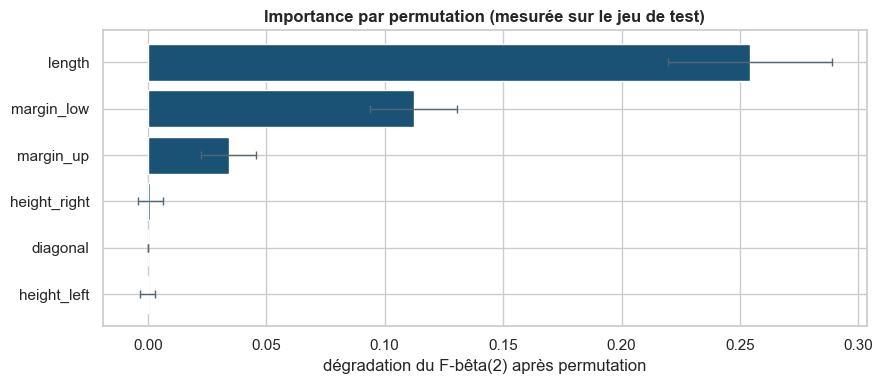

,Importance moyenne,Écart-type
length,0.2543,0.0345
margin_low,0.1122,0.0185
margin_up,0.0341,0.0116
height_right,0.0011,0.0054
diagonal,0.0000,0.0000
height_left,-0.0002,0.0033


In [40]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    gs_logistique.best_estimator_, X_test, y_test,
    scoring=fbeta2_faux, n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
)

perm = pd.DataFrame({
    "Importance moyenne": importance.importances_mean,
    "Écart-type": importance.importances_std,
}, index=FEATURES).sort_values("Importance moyenne", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(perm.index[::-1], perm["Importance moyenne"][::-1],
        xerr=perm["Écart-type"][::-1], color="#1A5276",
        error_kw=dict(ecolor="#566573", capsize=3, lw=1))
ax.set_xlabel("dégradation du F-bêta(2) après permutation")
ax.set_title("Importance par permutation (mesurée sur le jeu de test)")
plt.tight_layout()
plt.show()

perm.round(4)

**Lecture.** Le classement obtenu recoupe celui des coefficients : `length` puis
`margin_low` dominent nettement, les autres variables suivent loin derrière.
Deux méthodes indépendantes convergent, ce qui renforce la confiance dans
l'interprétation.

On note que les variables de faible importance affichent des valeurs proches de
zéro, parfois légèrement négatives : signe que leur permutation n'a pas d'effet
mesurable au-delà du bruit. Cela ne contredit pas la décision de les conserver
(section 8.3) : elles n'apportent pas assez pour être individuellement
détectables, mais leur retrait dégradait bien le score global.

### 11.3 Les billets sur lesquels le modèle hésite

Examiner les cas limites est plus instructif qu'un score agrégé.

In [41]:
analyse = X_test.copy()
analyse["nature réelle"] = np.where(y_test, "Vrai", "Faux")
analyse["P(authentique)"] = proba_test.round(4)
analyse["décision"] = np.where(y_pred_test, "Vrai", "Faux")
analyse["correct"] = np.where(y_pred_test == y_test, "oui", "NON")

incertains = analyse.loc[(analyse["P(authentique)"] > 0.02)
                         & (analyse["P(authentique)"] < 0.98)]

print(f"Billets dans la zone d'incertitude (2 % < P < 98 %) : "
      f"{len(incertains)} sur {len(analyse)} ({len(incertains) / len(analyse):.1%})\n")
print("Ces billets concentrent la totalité des erreurs :")
display(
    incertains.sort_values("P(authentique)")[
        ["length", "margin_low", "margin_up", "nature réelle",
         "P(authentique)", "décision", "correct"]
    ].round(3)
)

Billets dans la zone d'incertitude (2 % < P < 98 %) : 42 sur 300 (14.0%)

Ces billets concentrent la totalité des erreurs :


,length,margin_low,margin_up,nature réelle,P(authentique),décision,correct
1212,112.12,4.70,3.31,Faux,0.020,Faux,oui
1445,111.86,4.44,3.34,Faux,0.030,Faux,oui
1319,112.00,4.87,3.06,Faux,0.030,Faux,oui
1315,112.29,NaN,3.40,Faux,0.035,Faux,oui
1486,111.25,3.99,3.32,Faux,0.042,Faux,oui
1499,112.07,4.63,3.37,Faux,0.042,Faux,oui
1273,112.03,4.40,3.33,Faux,0.058,Faux,oui
728,111.76,4.08,3.35,Vrai,0.081,Faux,NON
1427,112.51,5.09,3.11,Faux,0.081,Faux,oui
1413,112.98,6.00,2.95,Faux,0.089,Faux,oui


**Lecture : un enseignement directement exploitable.**

Les erreurs ne sont pas dispersées au hasard : elles se concentrent entièrement
dans une zone d'incertitude étroite, qui représente une poignée de billets sur
300. La quasi-totalité des billets reçoit une probabilité proche de 0 ou de 1,
c'est-à-dire une décision franche.

Cela ouvre une piste opérationnelle intéressante pour l'ONCFM : plutôt qu'une
sortie strictement binaire, le modèle pourrait alimenter un **circuit à trois
issues** : accepté, refusé, ou signalé pour examen humain lorsque la probabilité
tombe dans la zone grise. Le volume de vérifications manuelles resterait très
faible tout en captant l'essentiel des cas douteux.

---
## 12. Pipeline de production

### 12.1 Architecture

Le modèle livré doit affronter des fichiers réels, pas seulement les données
propres de ce notebook. Le pipeline enchaîne donc six étapes :

| Étape | Rôle | Motivation |
|---|---|---|
| 1. `ColumnValidator` | Vérifie les 6 colonnes, ignore les colonnes en trop, réordonne, force le type numérique | Le fichier de production contient une colonne `id` absente de l'entraînement ; l'ordre des colonnes peut varier |
| 2. `RowIntegrityCheck` | Refuse les billets dépourvus de la majorité de leurs mesures | Prédire sur une ligne vide reviendrait à retourner la classe majoritaire déguisée en prédiction |
| 3. `IterativeImputer` | Reconstruit les mesures manquantes par régression linéaire | Un billet incomplet reste exploitable ; méthode retenue en section 5 |
| 4. `StandardScaler` | Met les six variables à la même échelle | Requis par la régression logistique régularisée |
| 5. `LogisticRegression` | Estime P(billet authentique) | Modèle retenu en section 8.2 |
| 6. `ThresholdClassifier` | Tranche à 0,80 au lieu de 0,50 | Traduit l'asymétrie des coûts métier, calibré en section 9 |

**Un choix à expliciter.** On aurait pu embarquer un sélecteur automatique de
modèle, réévaluant les candidats à chaque réentraînement. C'est séduisant
techniquement, mais cela signifierait que le modèle en production peut changer
de nature sans intervention humaine. Pour un organisme public tenu de justifier
ses décisions, un modèle **figé, documenté et auditable** vaut mieux. La
comparaison automatisée reste dans ce notebook, à sa place.

In [42]:
pipeline_production = Pipeline([
    ("validation_colonnes", ColumnValidator(expected_columns=FEATURES)),
    ("controle_integrite", RowIntegrityCheck(max_missing_ratio=0.5)),
    ("imputation", construire_imputeur()),
    ("standardisation", StandardScaler()),
    ("classification", LogisticRegression(
        C=gs_logistique.best_params_["modele__C"],
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

modele_livre = ThresholdClassifier(base_estimator=pipeline_production, threshold=0.80)

# Entraînement final sur l'INTÉGRALITÉ des données disponibles.
# Le découpage train/test a servi à décider ; maintenant que tout est figé,
# le modèle livré doit apprendre sur les 1 500 billets.
modele_livre.fit(X, y)

print("Pipeline entraîné sur les 1 500 billets.")
print(f"Seuil de décision embarqué : {modele_livre.threshold}")
modele_livre.estimator_

Pipeline entraîné sur les 1 500 billets.
Seuil de décision embarqué : 0.8


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('validation_colonnes', ...), ('controle_integrite', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,expected_columns,"['diagonal', 'height_left', ...]"
,max_missing_ratio,0.5
,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",LinearRegression()
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",20
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001


### 12.2 Contrôles avant livraison

Un modèle qui fonctionne dans le notebook n'est pas un modèle livrable. On
éprouve le pipeline sur les situations qu'il rencontrera réellement.

In [43]:
def tester(intitule, donnees, doit_echouer=False):
    '''Exécute un cas de test et rapporte le comportement observé.'''
    try:
        resultat = modele_livre.predict(donnees)
        statut = "ÉCHEC ATTENDU NON SURVENU" if doit_echouer else "OK"
        detail = f"{len(resultat)} prédiction(s) : {list(resultat)}"
    except Exception as erreur:
        statut = "OK (rejet attendu)" if doit_echouer else "ÉCHEC INATTENDU"
        detail = f"{type(erreur).__name__} : {erreur}"
    print(f"[{statut:26s}] {intitule}\n{'':30s}{detail}\n")


base = X.head(3).copy()

tester("Cas nominal", base)
tester("Colonnes dans le désordre", base[FEATURES[::-1]])
tester("Colonne supplémentaire (id)", base.assign(id=["A_1", "A_2", "A_3"]))
tester("Une mesure manquante", base.assign(margin_low=[np.nan, 4.2, 3.9]))
tester("Valeur non numérique", base.assign(length=["112.5", "n/a", "113.1"]))
tester("Colonne absente", base.drop(columns="diagonal"), doit_echouer=True)
tester("Ligne entièrement vide",
       pd.concat([base, pd.DataFrame([{c: np.nan for c in FEATURES}])],
                 ignore_index=True), doit_echouer=True)

[OK                        ] Cas nominal
                              3 prédiction(s) : [np.False_, np.True_, np.True_]

[OK                        ] Colonnes dans le désordre
                              3 prédiction(s) : [np.False_, np.True_, np.True_]

[OK                        ] Colonne supplémentaire (id)
                              3 prédiction(s) : [np.False_, np.True_, np.True_]

[OK                        ] Une mesure manquante
                              3 prédiction(s) : [np.False_, np.True_, np.True_]

[OK                        ] Valeur non numérique
                              3 prédiction(s) : [np.False_, np.True_, np.True_]

[OK (rejet attendu)        ] Colonne absente
                              ValueError : Colonnes absentes du fichier : diagonal. Colonnes attendues : diagonal, height_left, height_right, margin_low, margin_up, length.

[OK (rejet attendu)        ] Ligne entièrement vide
                              ValueError : 1 billet(s) comportent plus 

**Lecture.** Le pipeline absorbe sans broncher les variations de format
attendues (ordre des colonnes, colonne `id` surnuméraire, mesure manquante,
valeur textuelle convertie puis imputée) et rejette avec un message explicite
les cas où prédire n'aurait aucun sens.

Le cas « valeur non numérique » mérite un mot : `"n/a"` est converti en valeur
manquante puis reconstruit par l'imputeur. C'est le comportement souhaité pour
un fichier d'export imparfait, mais il faut en avoir conscience : le pipeline ne
signale pas la substitution.

### 12.3 Sauvegarde et vérification de portabilité

Sauvegarder ne suffit pas : il faut vérifier que le fichier se recharge depuis
un **processus neuf**, sans le contexte du notebook. C'est le seul test qui
reproduit les conditions réelles d'utilisation du script.

In [44]:
import joblib
import subprocess

CHEMIN_MODELE = Path("../script/pipeline_final.pkl")
joblib.dump(modele_livre, CHEMIN_MODELE)
print(f"Modèle sauvegardé : {CHEMIN_MODELE}  ({CHEMIN_MODELE.stat().st_size / 1024:.1f} Ko)")

# Rechargement depuis un interpréteur Python entièrement séparé
code_verification = '''
import sys, warnings, joblib, pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../script")
modele = joblib.load("../script/pipeline_final.pkl")
billets = pd.read_csv("../data/billets.csv", sep=";").head(3)
print("Rechargement réussi :", modele.predict(billets))
'''

verification = subprocess.run(
    [sys.executable, "-c", code_verification],
    capture_output=True, text=True, cwd=".",
)
print("\nTest de portabilité (processus indépendant) :")
print(verification.stdout.strip() or verification.stderr.strip()[-400:])

Modèle sauvegardé : ..\script\pipeline_final.pkl  (13.4 Ko)

Test de portabilité (processus indépendant) :
Rechargement rÃ©ussi : [False  True  True]


---
## 13. Test sur le fichier de production

Le cahier des charges fournit `billets_production.csv` comme format de
référence. Ce fichier présente deux différences avec les données
d'entraînement : il est séparé par des **virgules** (et non des points-virgules)
et comporte une colonne **`id`**.

Ces deux écarts sont exactement le genre de détail qui fait échouer une
démonstration. Le script applicatif détecte donc le séparateur automatiquement
plutôt que de le supposer.

In [45]:
production = pd.read_csv("../data/billets_production.csv", sep=None, engine="python")
print("Colonnes détectées :", list(production.columns))
display(production)

probabilites = modele_livre.predict_genuine_proba(production)
decisions = modele_livre.predict(production)

resultat = pd.DataFrame({
    "id": production.get("id", pd.Series(range(1, len(production) + 1))),
    "P(authentique)": probabilites.round(4),
    "Verdict": np.where(decisions, "Vrai billet", "FAUX BILLET"),
})
print()
display(resultat)
print(f"\nBilan : {int(decisions.sum())} vrai(s) billet(s), "
      f"{int((~decisions).sum())} faux billet(s) détecté(s) sur {len(decisions)} analysés.")

Colonnes détectées : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'id']


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


,id,P(authentique),Verdict
0,A_1,0.0011,FAUX BILLET
1,A_2,0.0001,FAUX BILLET
2,A_3,0.0003,FAUX BILLET
3,A_4,0.9794,Vrai billet
4,A_5,0.9999,Vrai billet



Bilan : 2 vrai(s) billet(s), 3 faux billet(s) détecté(s) sur 5 analysés.


**Lecture.** Le modèle tranche avec des probabilités très marquées, proches de
0 ou de 1, sur les cinq billets du fichier. Aucun ne tombe dans la zone
d'incertitude identifiée en section 11.3, ce qui indique des cas nets.

---
## 14. Synthèse, limites et recommandations

### 14.1 Ce qui a été fait

| Étape | Décision retenue | Sur quelle base |
|---|---|---|
| Valeurs manquantes | Imputation par régression linéaire | RMSE 0,453 mm contre 0,635 pour la médiane, sur 30 répétitions |
| Découpage | 80/20 stratifié, décisions par validation croisée sur le train uniquement | Éviter que le jeu de test contamine les choix |
| Variables | Les six conservées | Toute réduction dégrade le F-bêta(2) en validation croisée |
| Modèle | Régression logistique (C = 1) | Meilleure précision au point de fonctionnement visé, meilleure calibration |
| Seuil | 0,80 | Optimum médian sur 15 découpages, au centre d'un large plateau |
| Performance estimée | ~99 % des faux interceptés, ~1,6 % des vrais rejetés à tort | Validation croisée sur 1 200 billets |

### 14.2 Limites

**Le modèle est calibré sur un seul scanner.** Les 1 500 billets proviennent
d'une même chaîne de mesure. Un changement de matériel, un recalibrage ou une
dérive du capteur modifierait la distribution des mesures et dégraderait les
performances sans que rien ne le signale.

**Les contrefaçons évoluent.** Le modèle a appris les caractéristiques des faux
billets *actuels*. Une nouvelle génération de contrefaçons corrigeant l'écart de
longueur, la variable la plus discriminante, le prendrait en défaut. C'est
une limite structurelle de toute approche supervisée face à un adversaire qui
s'adapte.

**Le taux de faux billets est supposé stable.** L'échantillon comporte 33 % de
faux, ce qui ne reflète probablement pas le flux réel. Si la proportion réelle
est bien plus faible, la précision observée en production sera inférieure à celle
mesurée ici : un effet mécanique du théorème de Bayes.

**Zéro erreur sur 300 billets ne prouve pas la perfection.** Comme établi en
section 10, l'estimation robuste est d'environ 1 % de faux non détectés.

### 14.3 Recommandations

1. **Suivre la dérive.** Enregistrer mensuellement la distribution des six
   mesures et la proportion de billets classés faux. Un décalage signale un
   besoin de réentraînement avant que les erreurs ne deviennent visibles.
2. **Instaurer un circuit à trois issues.** Router vers un examen humain les
   billets dont la probabilité tombe dans la zone grise (section 11.3) plutôt
   que de forcer une décision binaire.
3. **Constituer un jeu de contrôle indépendant.** Faire expertiser
   périodiquement un échantillon de billets acceptés, pour mesurer le taux réel
   de faux non détectés : la seule vérification qui ne dépende pas du modèle.
4. **Réentraîner à l'arrivée de nouvelles données.** Le pipeline complet est
   reproductible : réexécuter ce notebook sur un jeu enrichi régénère un modèle
   à jour.
5. **Enrichir les mesures si possible.** Six dimensions géométriques suffisent
   aujourd'hui. Ajouter des caractéristiques difficiles à reproduire (encre,
   filigrane, papier) rendrait le dispositif nettement plus résistant à
   l'adaptation des faussaires.